# RSS Change for a Given Gamma

Examines how the RSS of packets changes while the angle the transmitter faces when it transmits those packets remains constant.

For the `Range Trials/` experiments, the tag didn't move at all, meaning there should be very little change.

In [1]:
from BleFinley import *
from BleFinley.pymc_learning import *
from BleFinley.rss_difference import *

In [2]:
tx_a = Transmitter('a', -1.448596, 53.368606, 131.0 + 1.5)
tx_b = Transmitter('b', -1.448626, 53.367865, 131.0 + 1.5)
tx_c = Transmitter('c', -1.450168, 53.368359, 122.0 + 1.5)
tx_e = Transmitter('e', -1.449990, 53.369204, 118.0 + 1.5)

## Examine Range Trial 7

Look at the difference in RSS just for gamma = 0, and then look at a combined histogram of all angles from 0-360 degrees.

BleLog | tx: c, no.packets: 1533, time: 86.140s


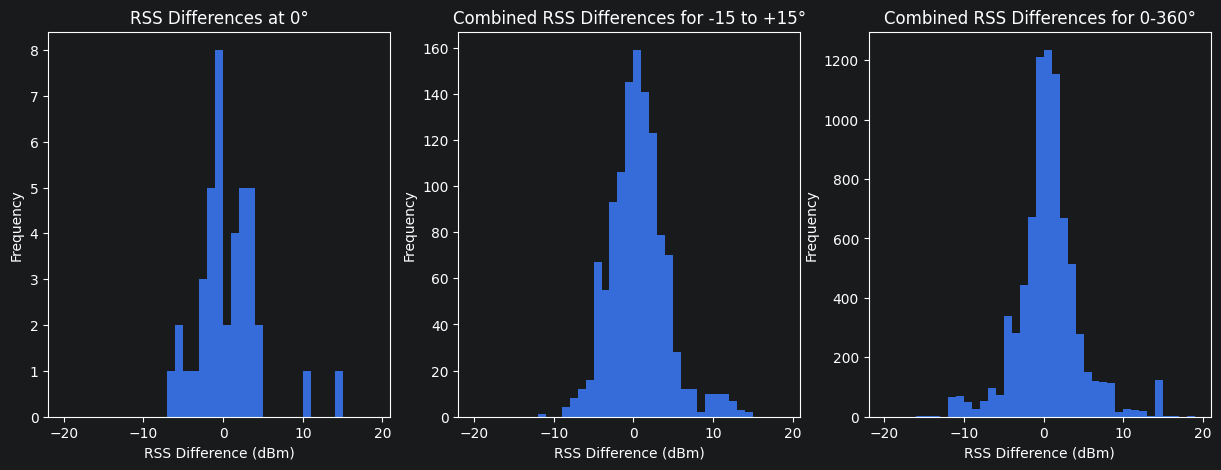

In [2]:
range_7_log = BleLog("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/7.log", tx_c, None)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("RSS Differences at 0°")
plt.ylabel("Frequency")
plt.xlabel("RSS Difference (dBm)")
plt.hist(rss_diff_at_gamma(range_7_log, 0), bins=np.arange(-20, 20))

plt.subplot(1, 3, 2)
diffs = []

for degree in range(-15, 15):
    diffs.extend(rss_diff_at_gamma(range_7_log, degree))

plt.hist(diffs, bins=np.arange(-20, 20))
plt.title(f"Combined RSS Differences for -15 to +15°")
plt.ylabel("Frequency")
plt.xlabel("RSS Difference (dBm)")

plt.subplot(1, 3, 3)
diffs = []

for degree in range(0, 359):
    diffs.extend(rss_diff_at_gamma(range_7_log, degree))

plt.hist(diffs, bins=np.arange(-20, 20))
plt.title("Combined RSS Differences for 0-360°")
plt.ylabel("Frequency")
plt.xlabel("RSS Difference (dBm)")
plt.show()

## Examine All Range Trials Together

For all the range trials in `/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/`, examine the difference in RSS between two packets (sequential or with a large gap between them) for a given gamma. Collate this information into blocks of 30 degrees and then combine the data for all angles. The values of gamma for each packet are normalised so 0 degrees is pointing directly at the bee tag.

In [3]:
# parse all range trials into a dictionary
range_logs :dict[str, BleLog] = {}
range_trial_folder = "/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/"

range_logs["1.log"] = BleLogStatic(range_trial_folder + "1.log", tx_c, -1.449861, 53.368415, 128.1)
range_logs["2.log"] = BleLogStatic(range_trial_folder + "2.log", tx_c, -1.449851, 53.368798, 124.3)
range_logs["3.log"] = BleLogStatic(range_trial_folder + "3.log", tx_c, -1.449712, 53.369261, 111.0)
range_logs["4.log"] = BleLogStatic(range_trial_folder + "4.log", tx_c, -1.449732, 53.369659, 123.5)
range_logs["5.log"] = BleLogStatic(range_trial_folder + "5.log", tx_c, -1.449705, 53.369932, 112.0)
range_logs["6.log"] = BleLogStatic(range_trial_folder + "6.log", tx_c, -1.449617, 53.370239, 111.2)
range_logs["7.log"] = BleLogStatic(range_trial_folder + "7.log", tx_c, -1.449647, 53.370649, 106.6)
range_logs["8.log"] = BleLogStatic(range_trial_folder + "8.log", tx_c, -1.449575, 53.371191, 104.9)
range_logs["9.log"] = BleLogStatic(range_trial_folder + "9.log", tx_c, -1.449595, 53.371545, 107.7)

BleLog | tx: c, no.packets: 8314, time: 86.369s
BleLogStatic | angle offset: -74.055
BleLog | tx: c, no.packets: 3108, time: 75.356s
BleLogStatic | angle offset: -23.199
BleLog | tx: c, no.packets: 3208, time: 89.925s
BleLogStatic | angle offset: -16.699
BleLog | tx: c, no.packets: 6502, time: 87.054s
BleLogStatic | angle offset: -10.929
BleLog | tx: c, no.packets: 1518, time: 91.795s
BleLogStatic | angle offset: -9.728
BleLog | tx: c, no.packets: 93, time: 71.421s
BleLogStatic | angle offset: -9.507
BleLog | tx: c, no.packets: 1533, time: 86.140s
BleLogStatic | angle offset: -7.374
BleLog | tx: c, no.packets: 1536, time: 96.692s
BleLogStatic | angle offset: -6.699
BleLog | tx: c, no.packets: 2864, time: 73.173s
BleLogStatic | angle offset: -5.807


### Sequential Packet Differences

The difference is taken between the current packet and the packet at the same gamma in the next transmitter rotation (approximately 2 seconds later). Examine the RSS in 30 degree blocks using histograms, and then all angles combined into one histogram.

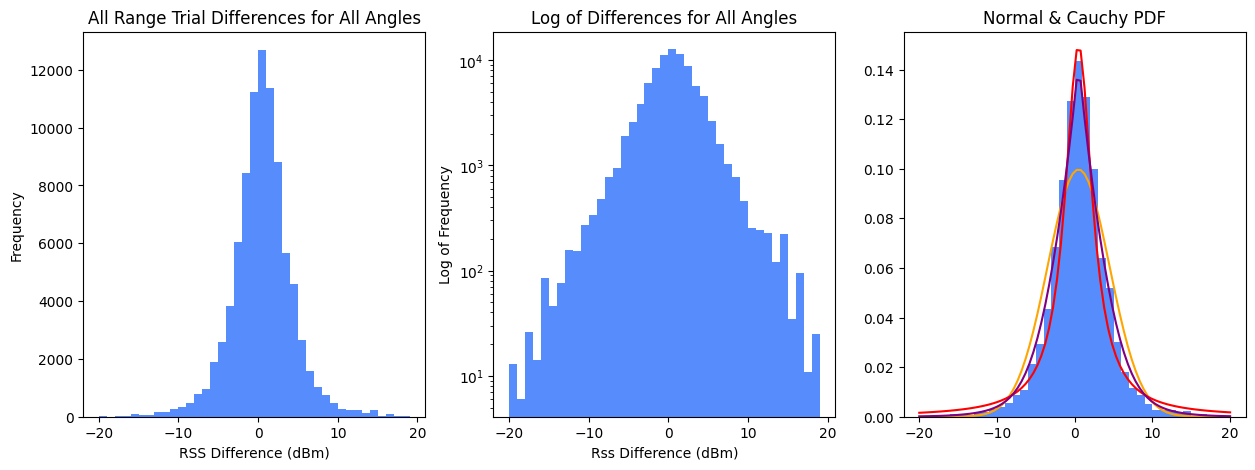

In [4]:
diffs_1 = combined_rss_at_gamma_analysis(range_logs, 1)
x_axis = np.linspace(-20, 20, 1000)

plt.show()

#### -15 to 15 Degrees

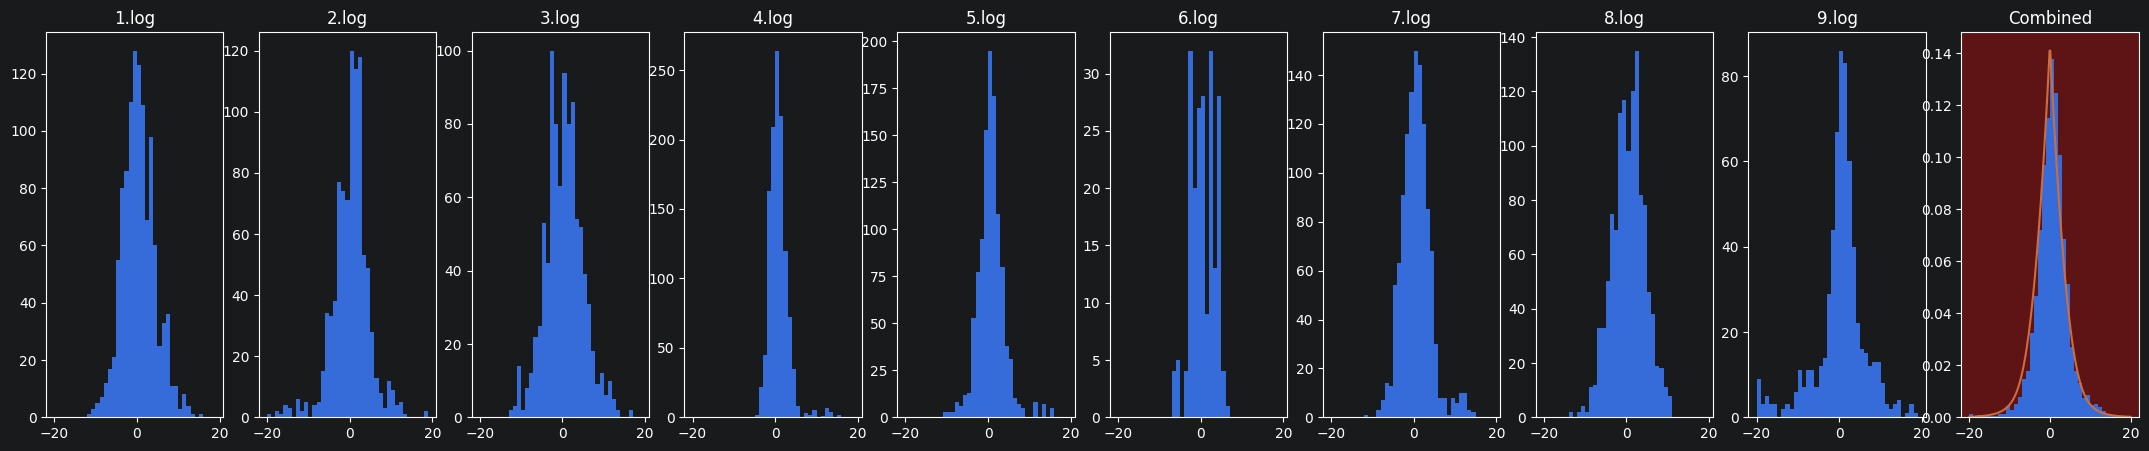

#### 15 to 45 Degrees

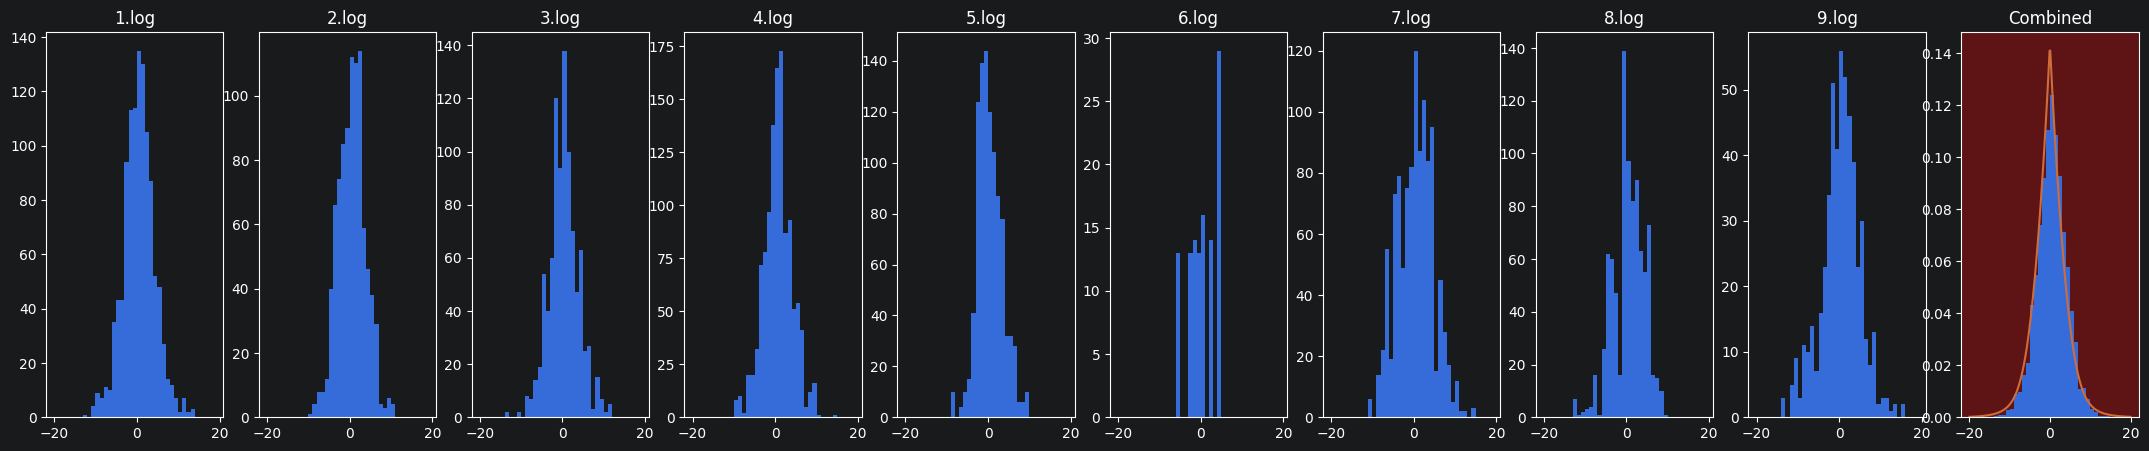

#### 45 to 75 Degrees

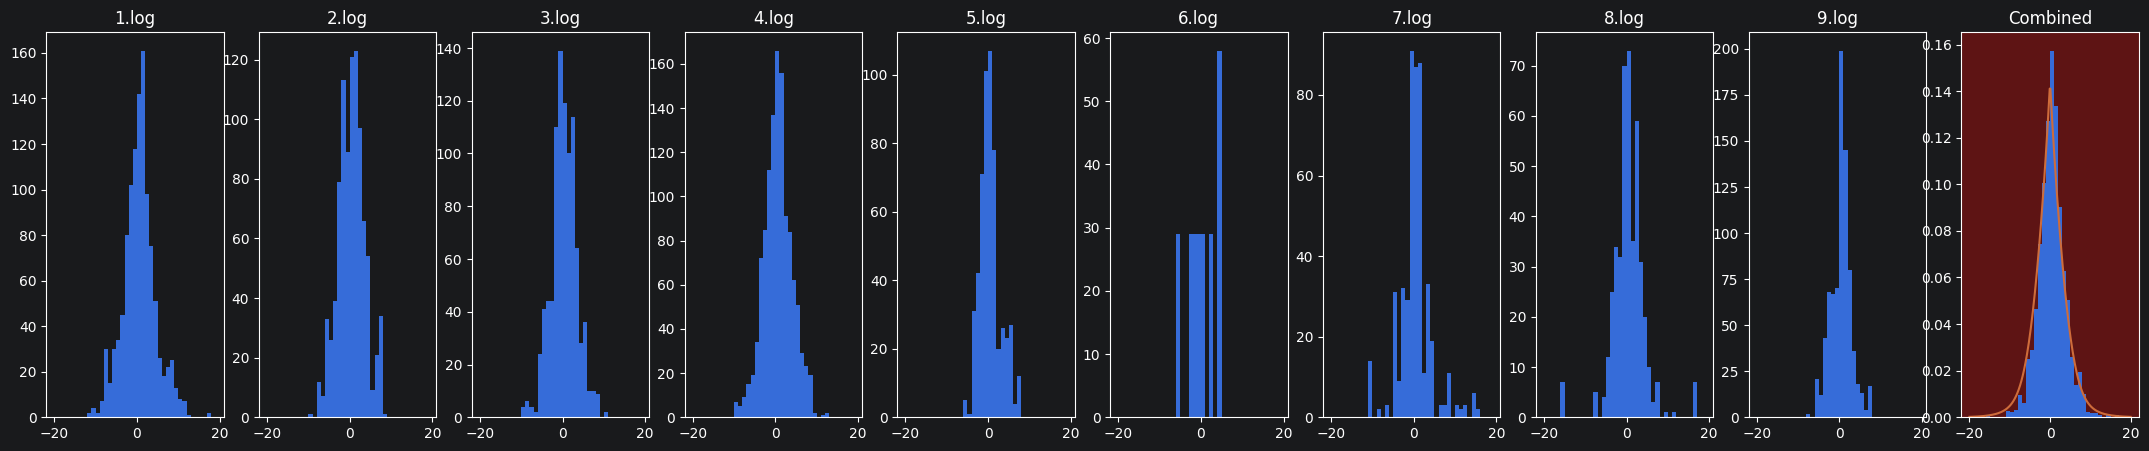

#### 75 to 105 Degrees

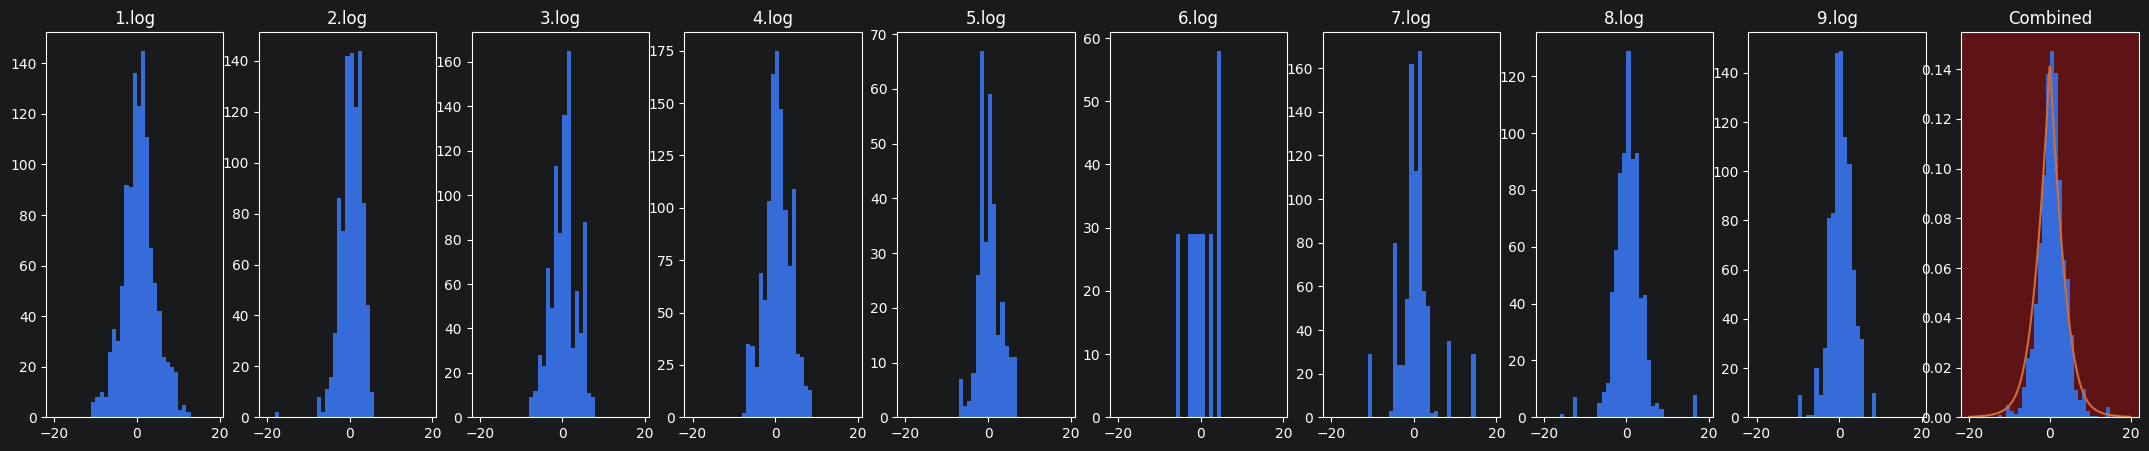

#### 105 to 135 Degrees

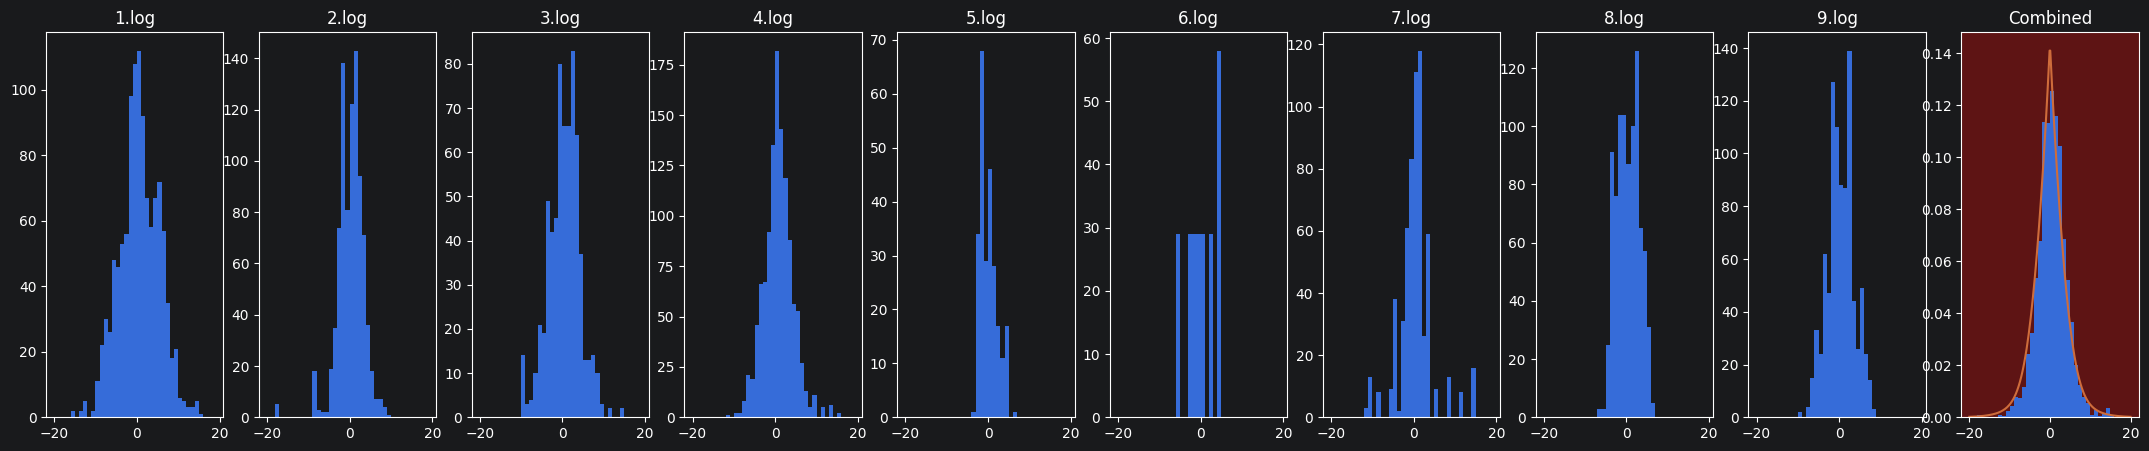

#### 135 to 165 Degrees

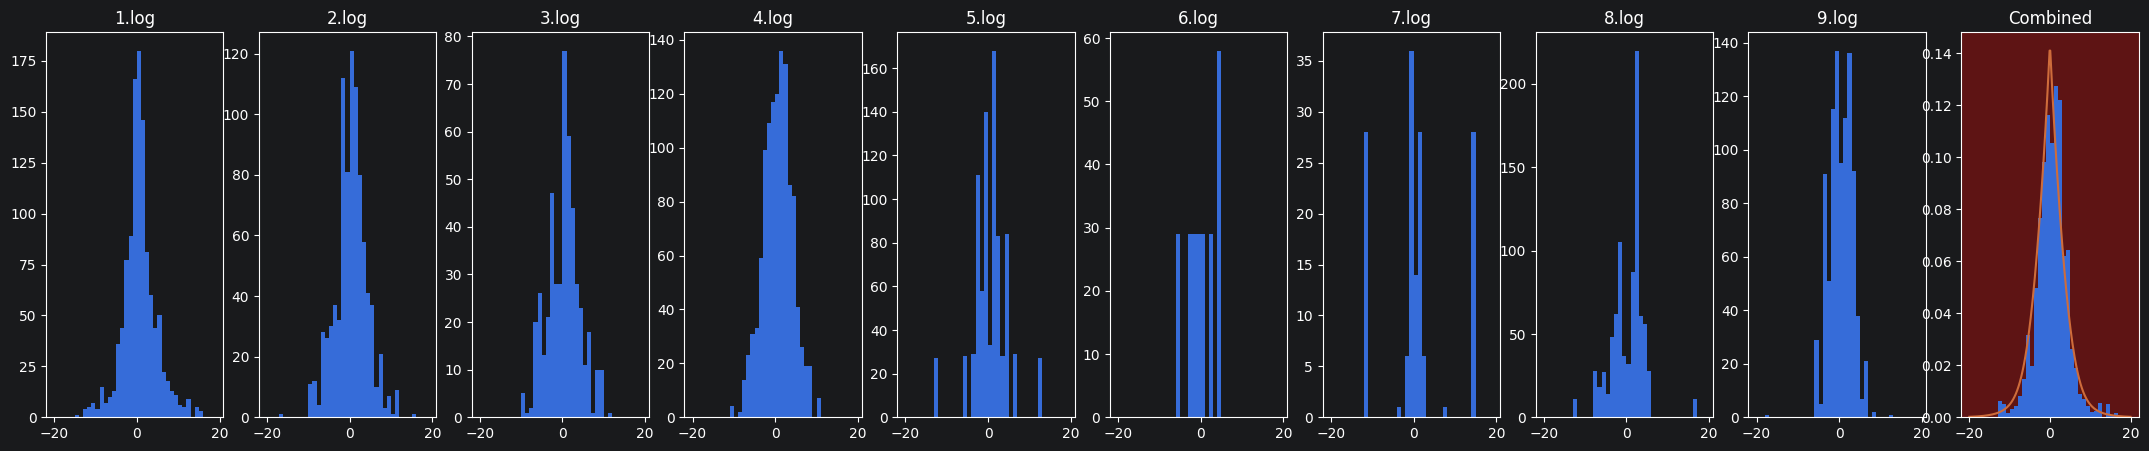

#### 165 to 195 Degrees

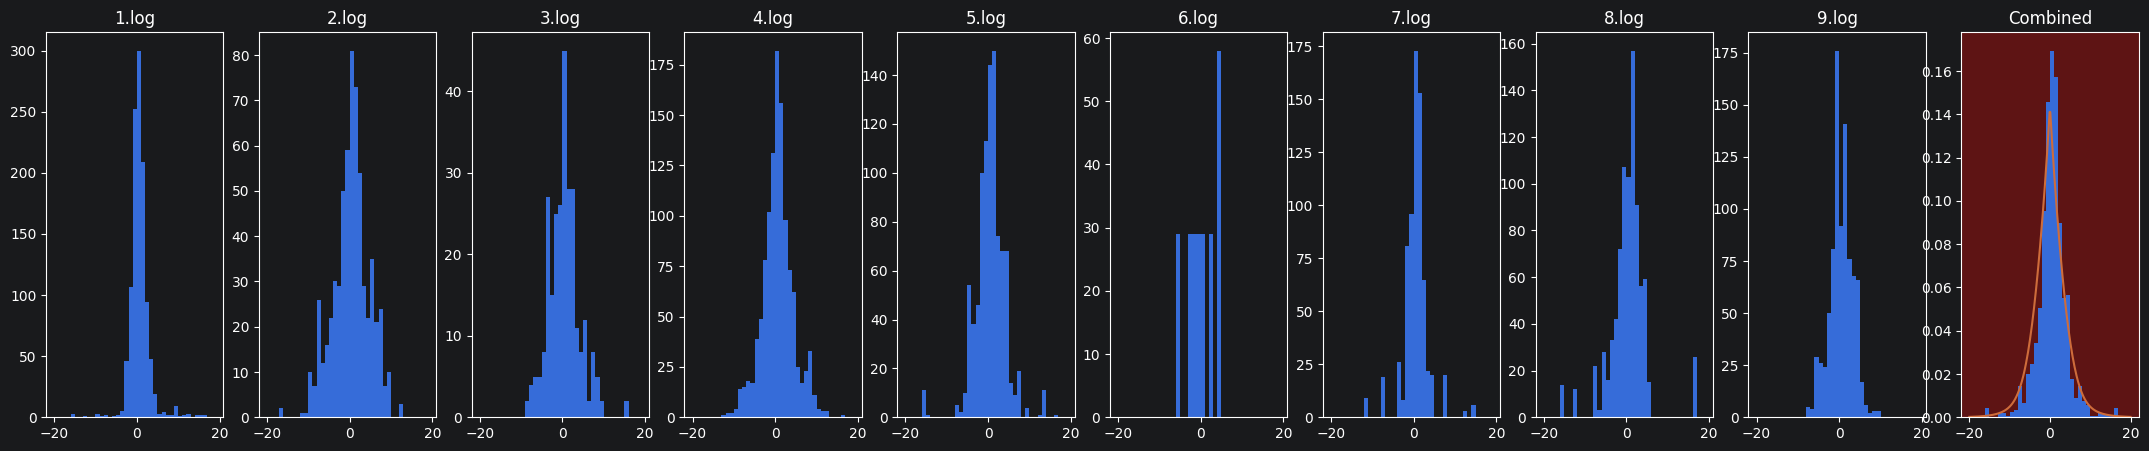

#### 195 to 225 Degrees

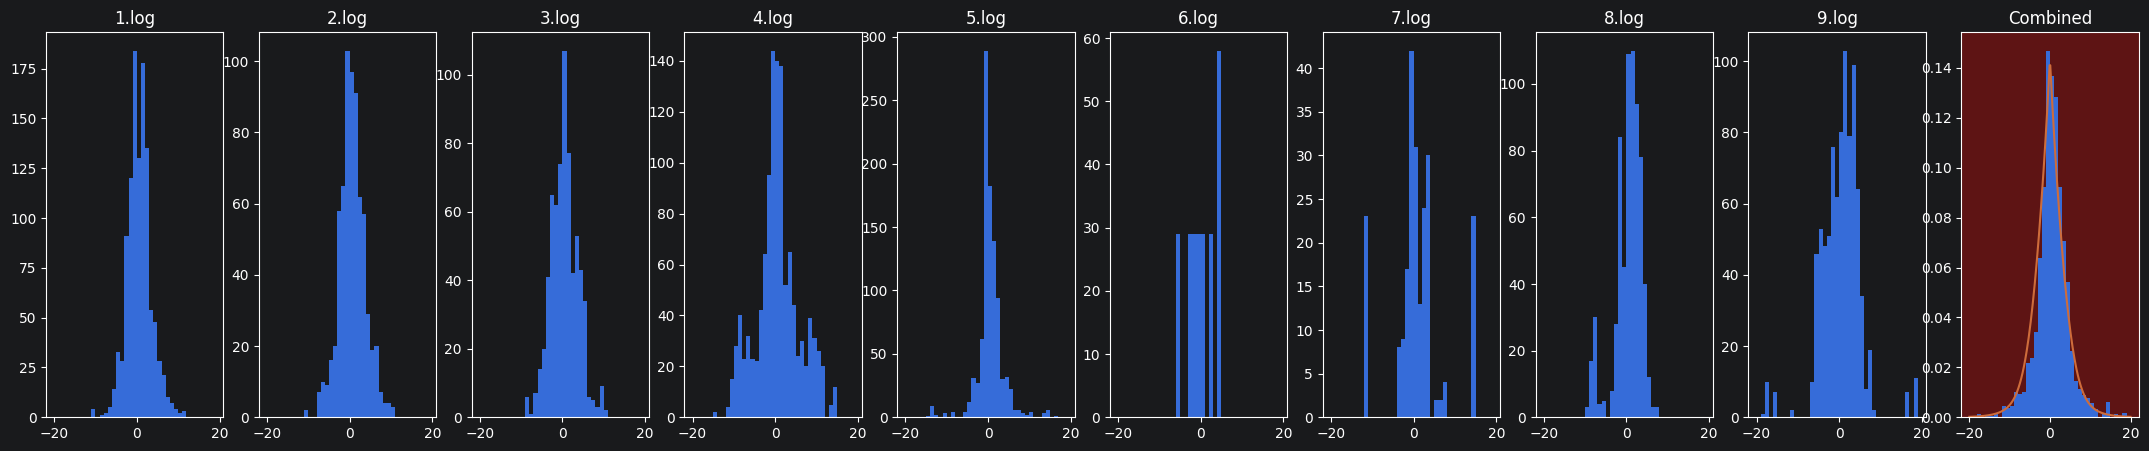

#### 225 to 255 Degrees

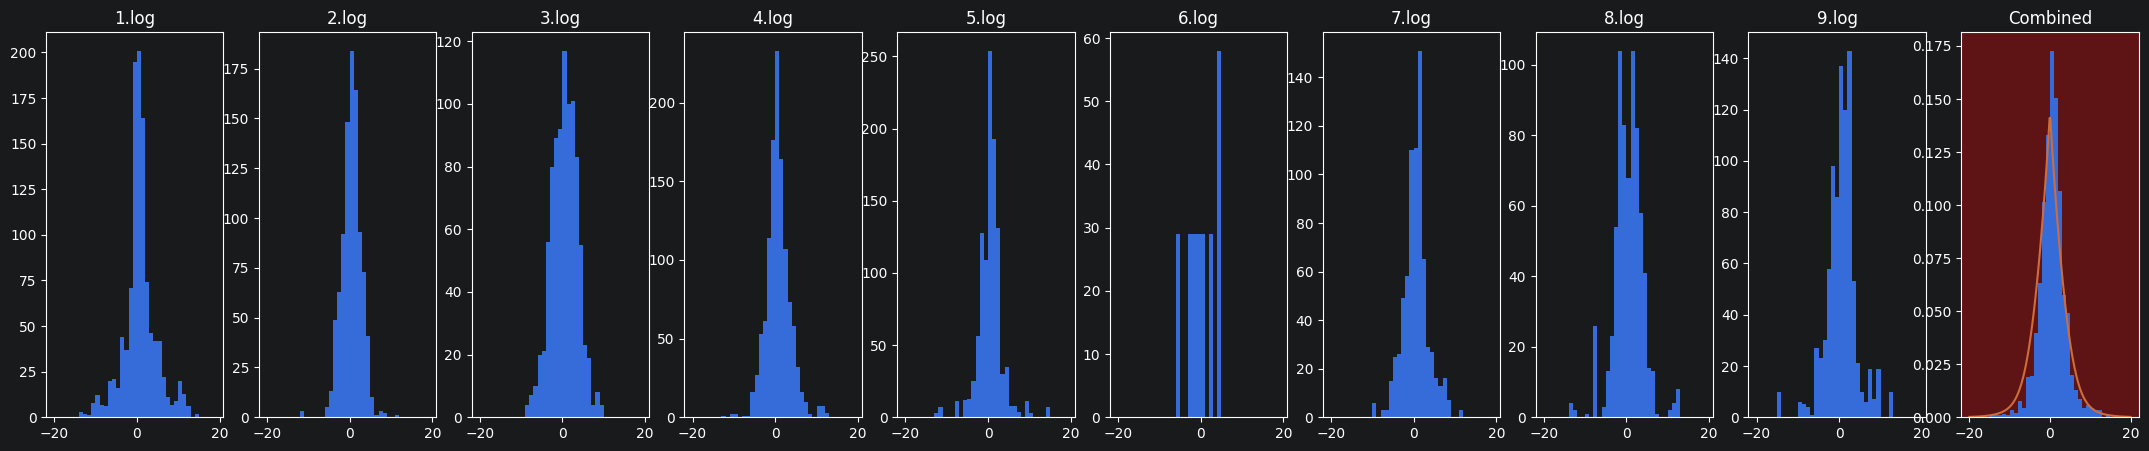

#### 255 to 285 Degrees

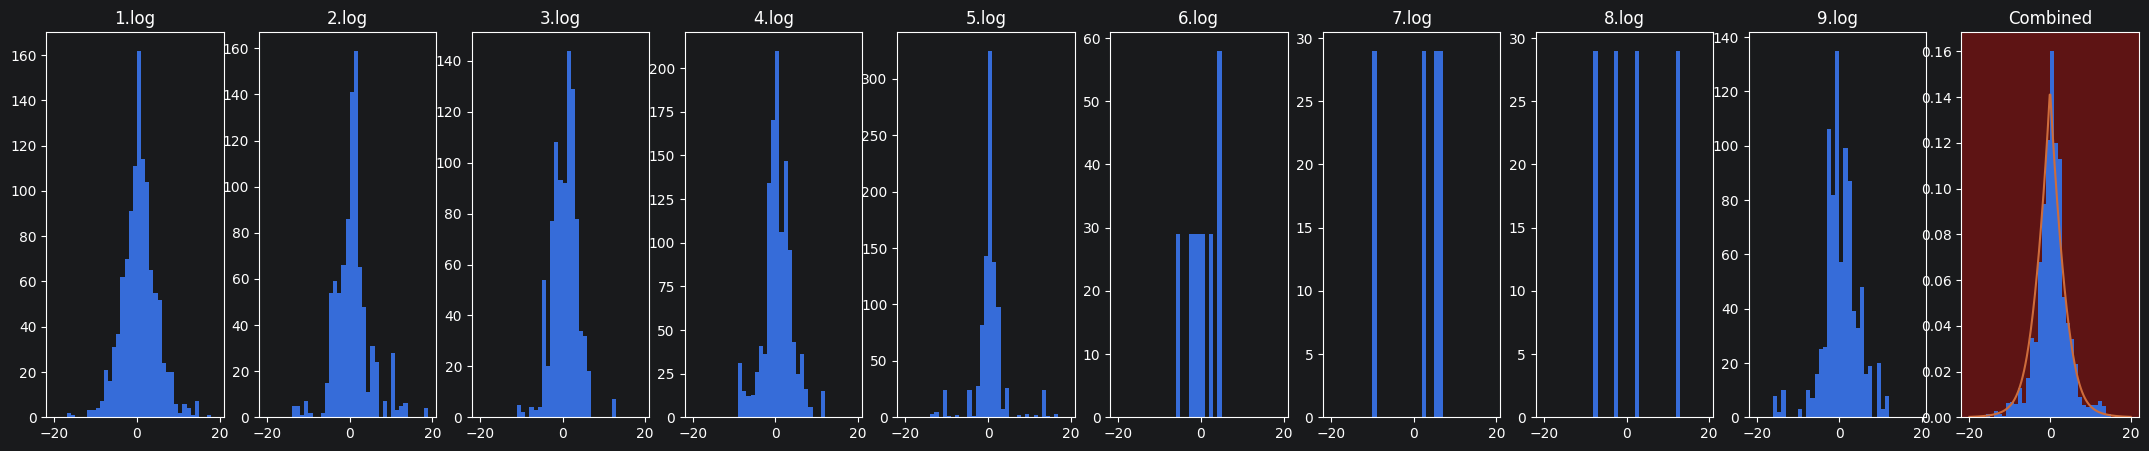

#### 285 to 315 Degrees

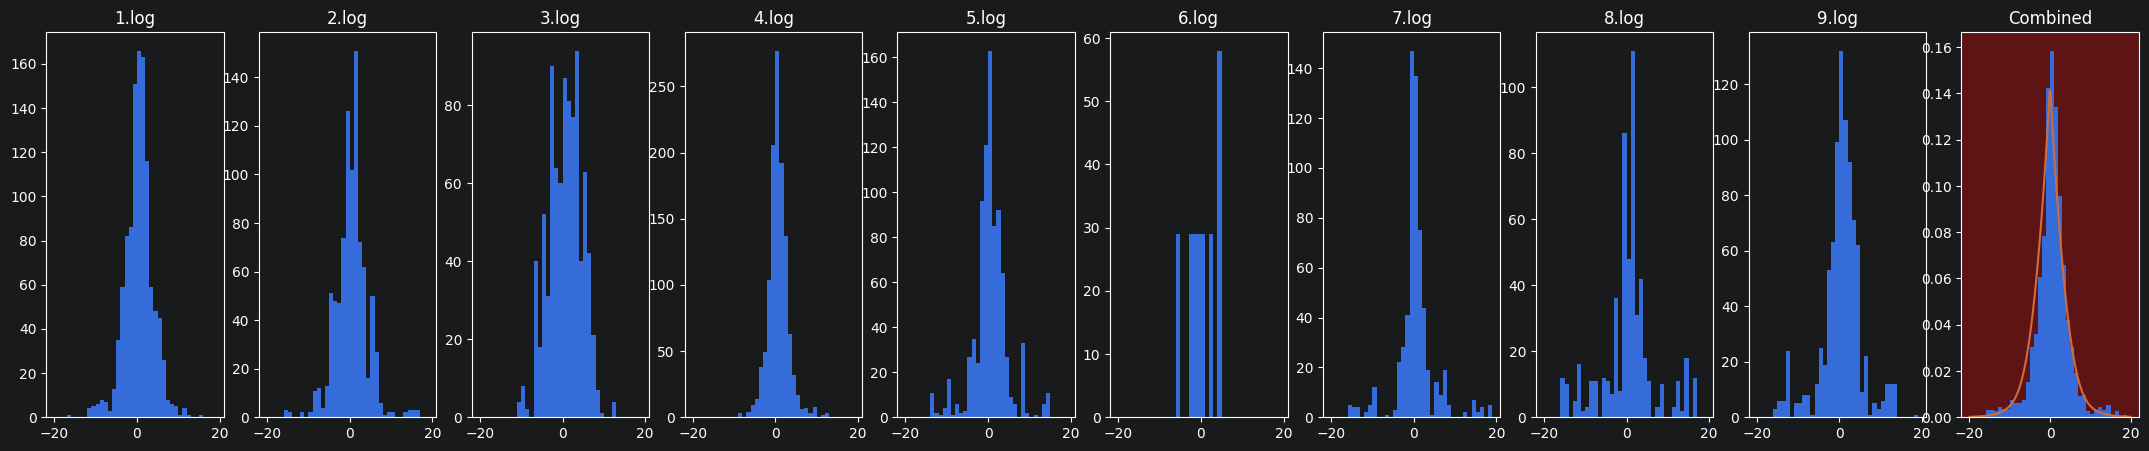

#### 315 to 345 Degrees

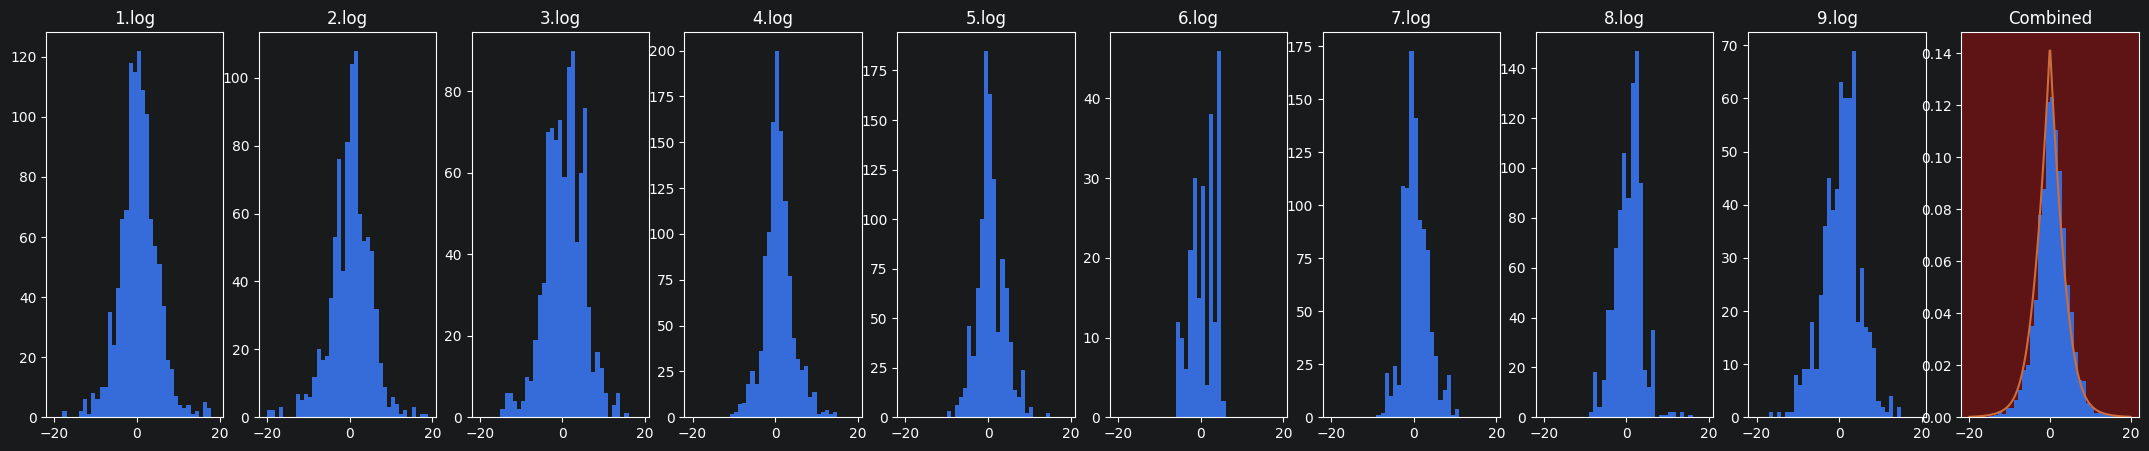

In [5]:
range_trial_rss_diffs_in_blocks(range_logs)

### Two Packet Differences

This would be applicable if a sample is taken over 4 seconds

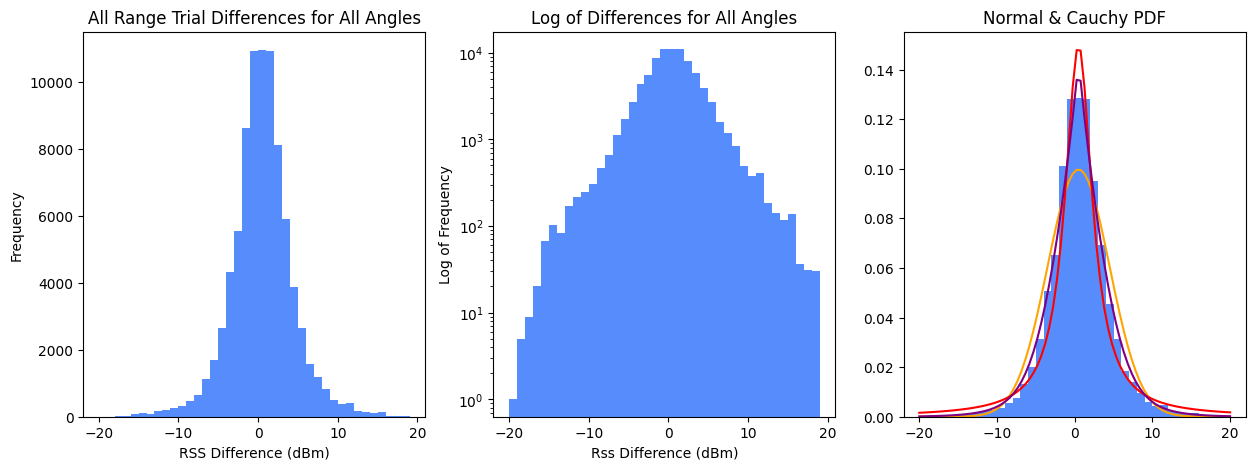

In [5]:
diffs_2 = combined_rss_at_gamma_analysis(range_logs, 2)

#### -15 to 15 Degrees

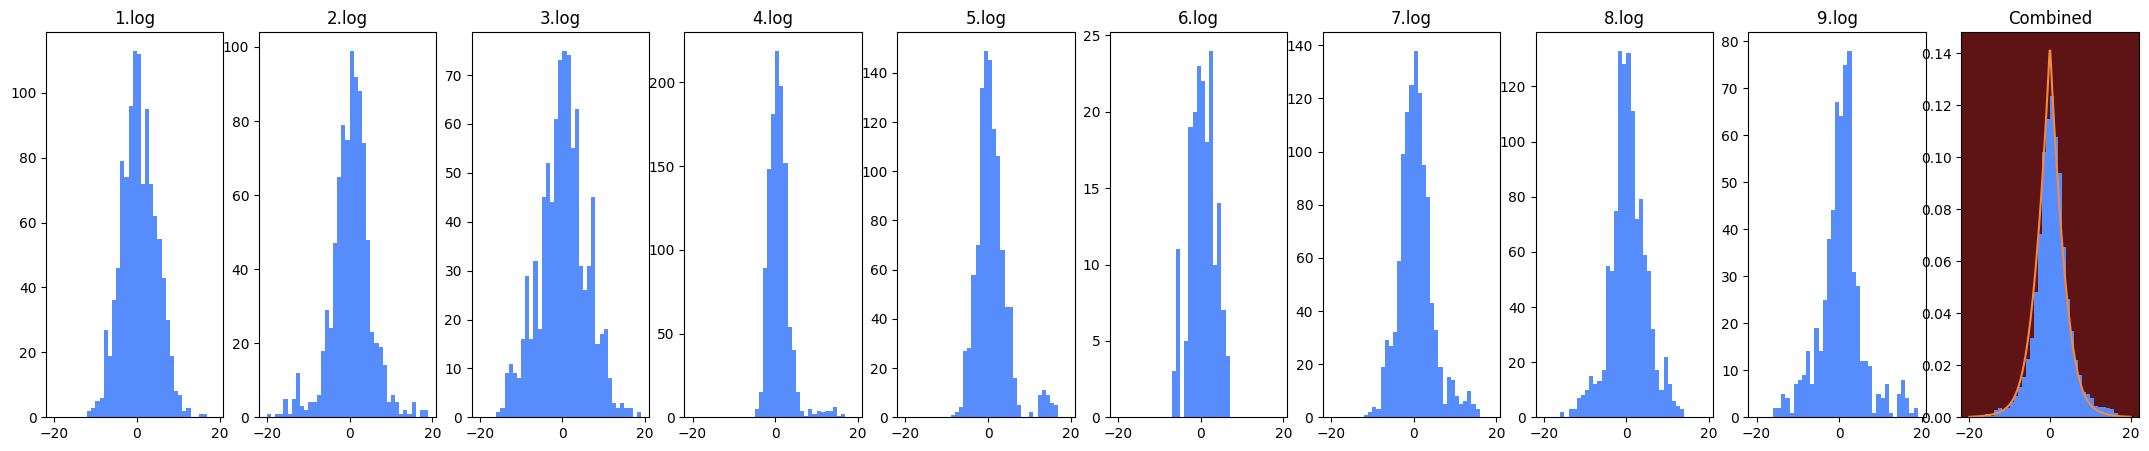

#### 15 to 45 Degrees

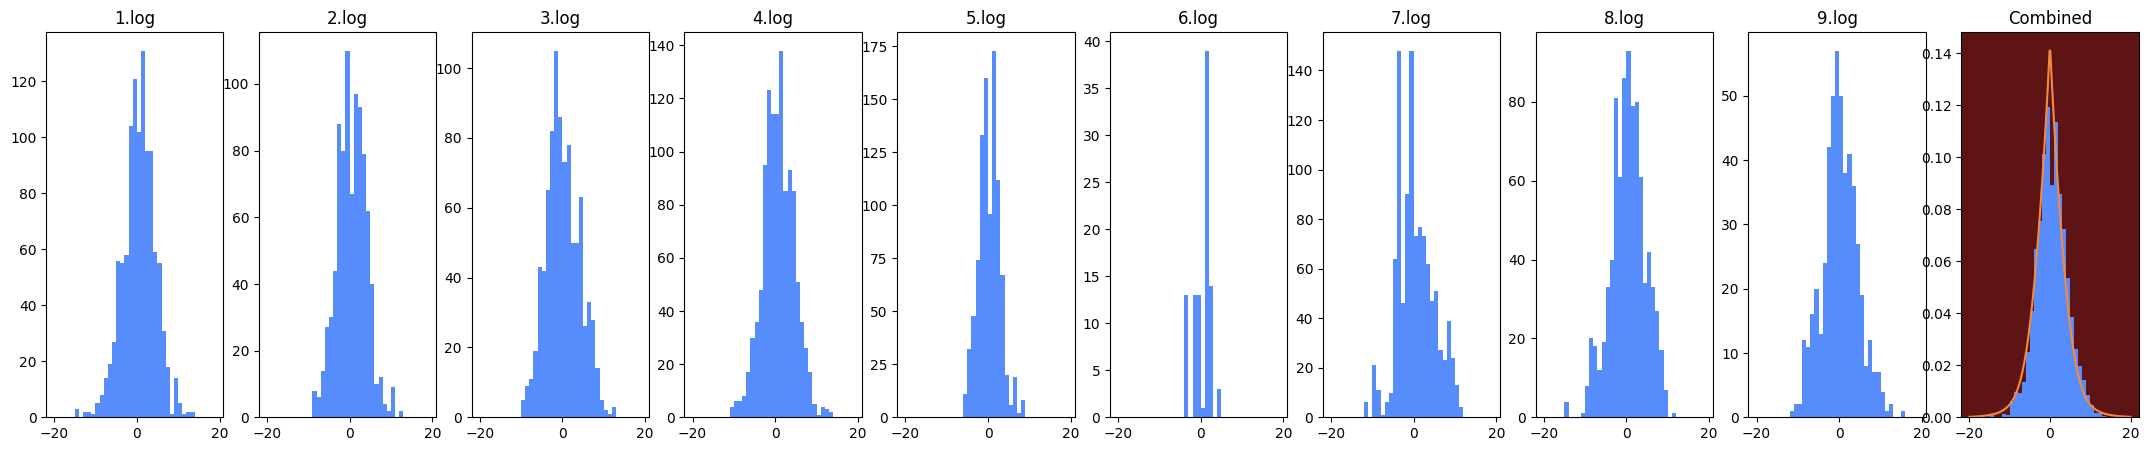

#### 45 to 75 Degrees

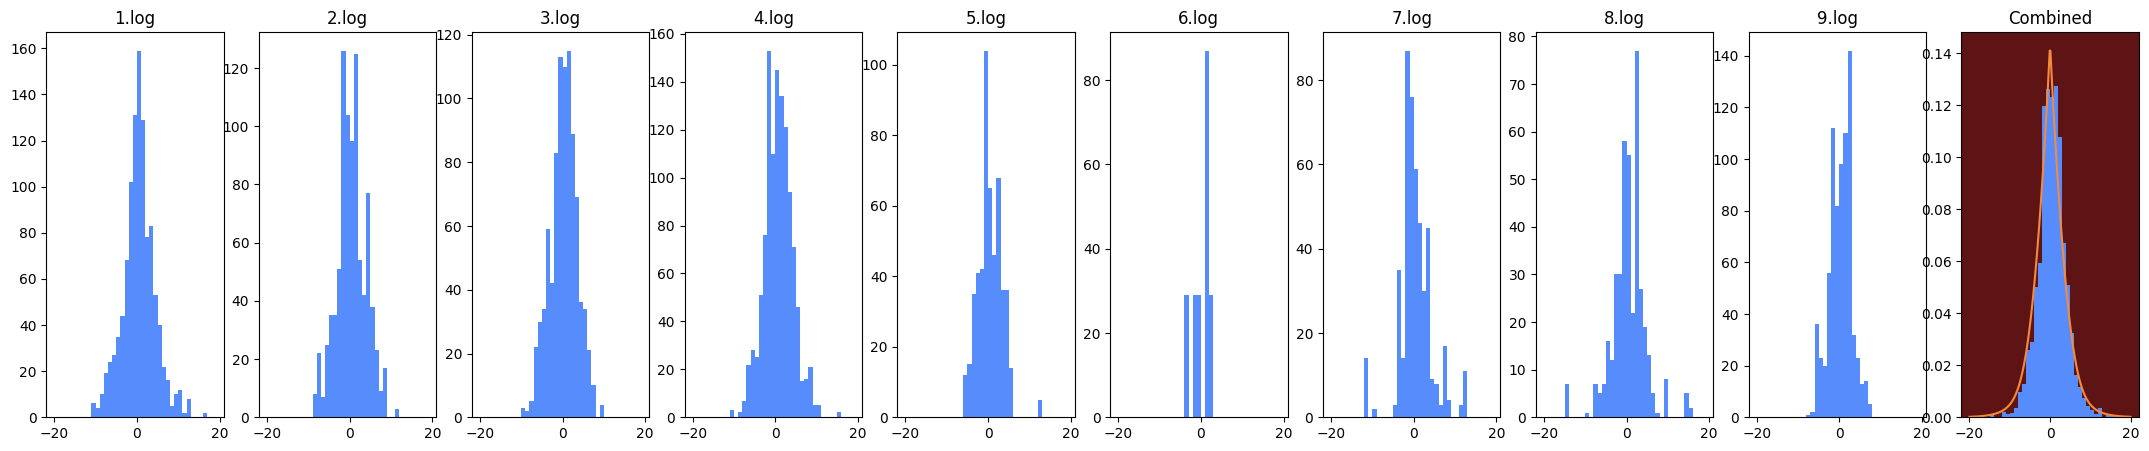

#### 75 to 105 Degrees

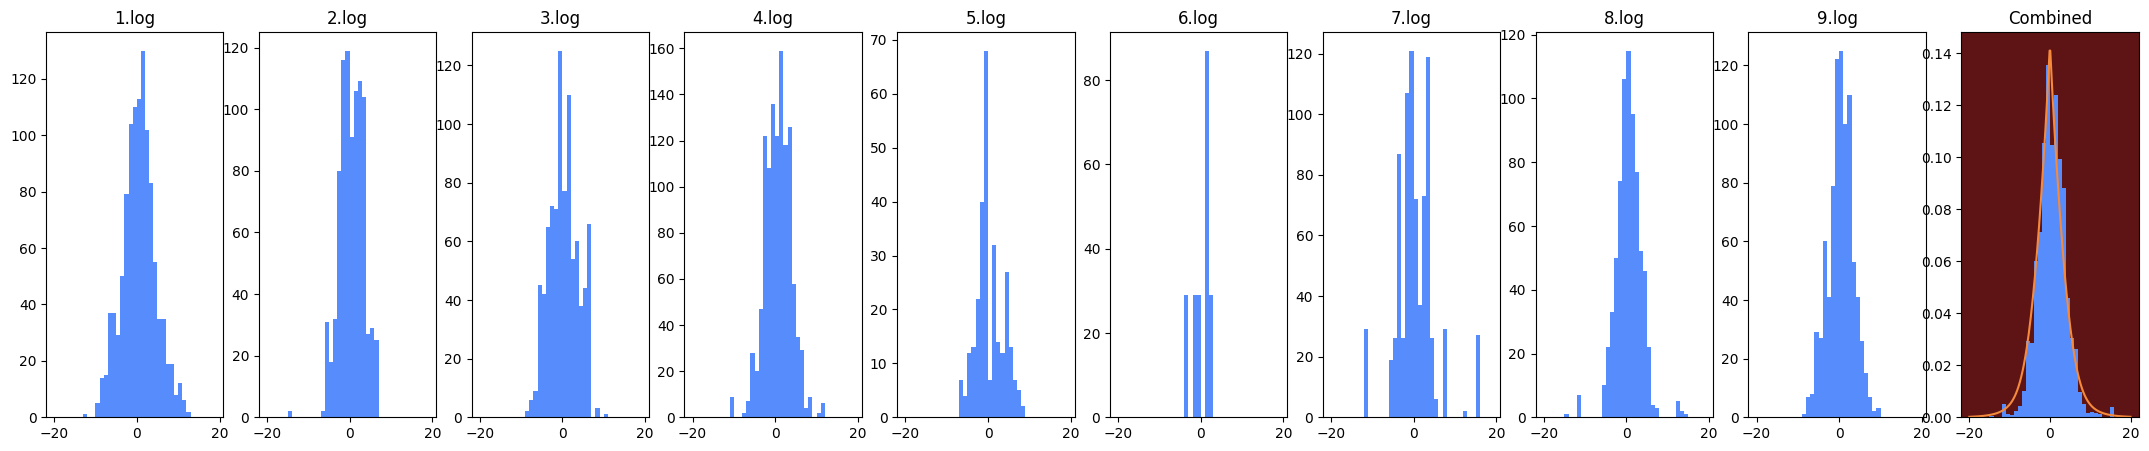

#### 105 to 135 Degrees

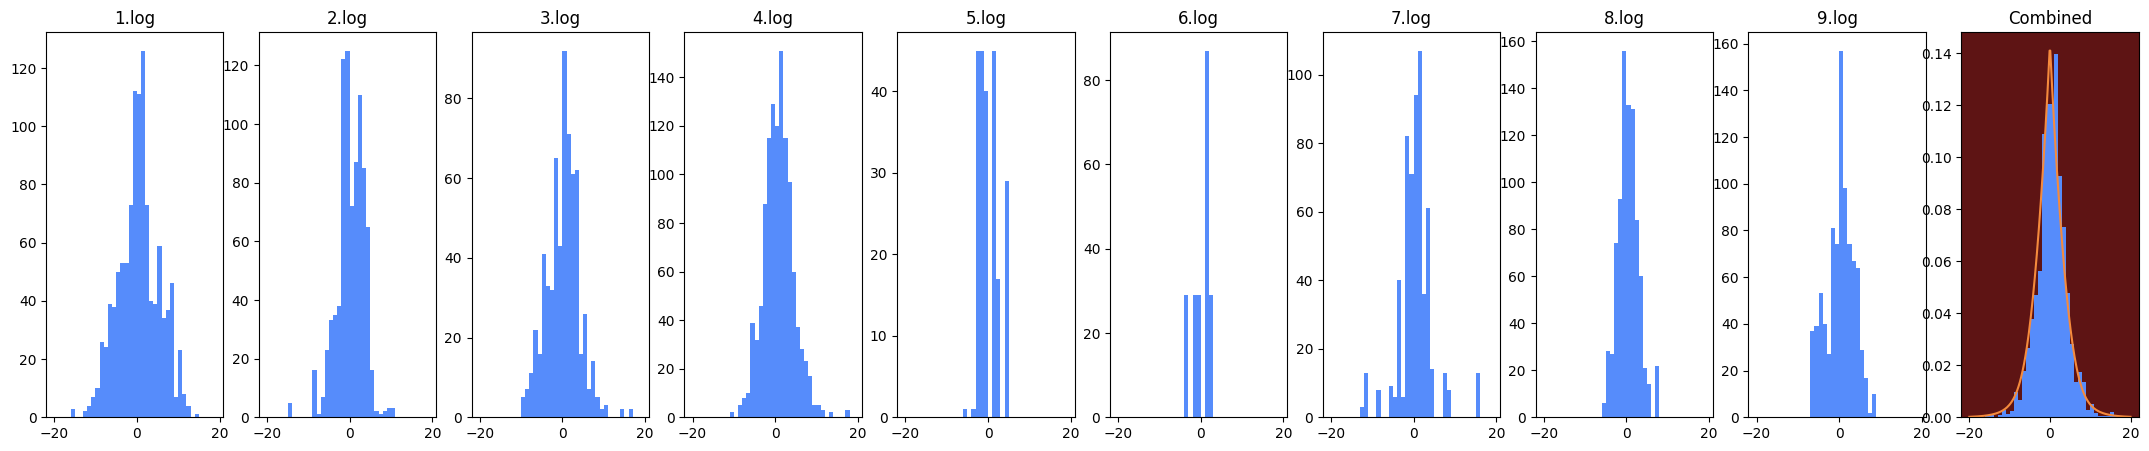

#### 135 to 165 Degrees

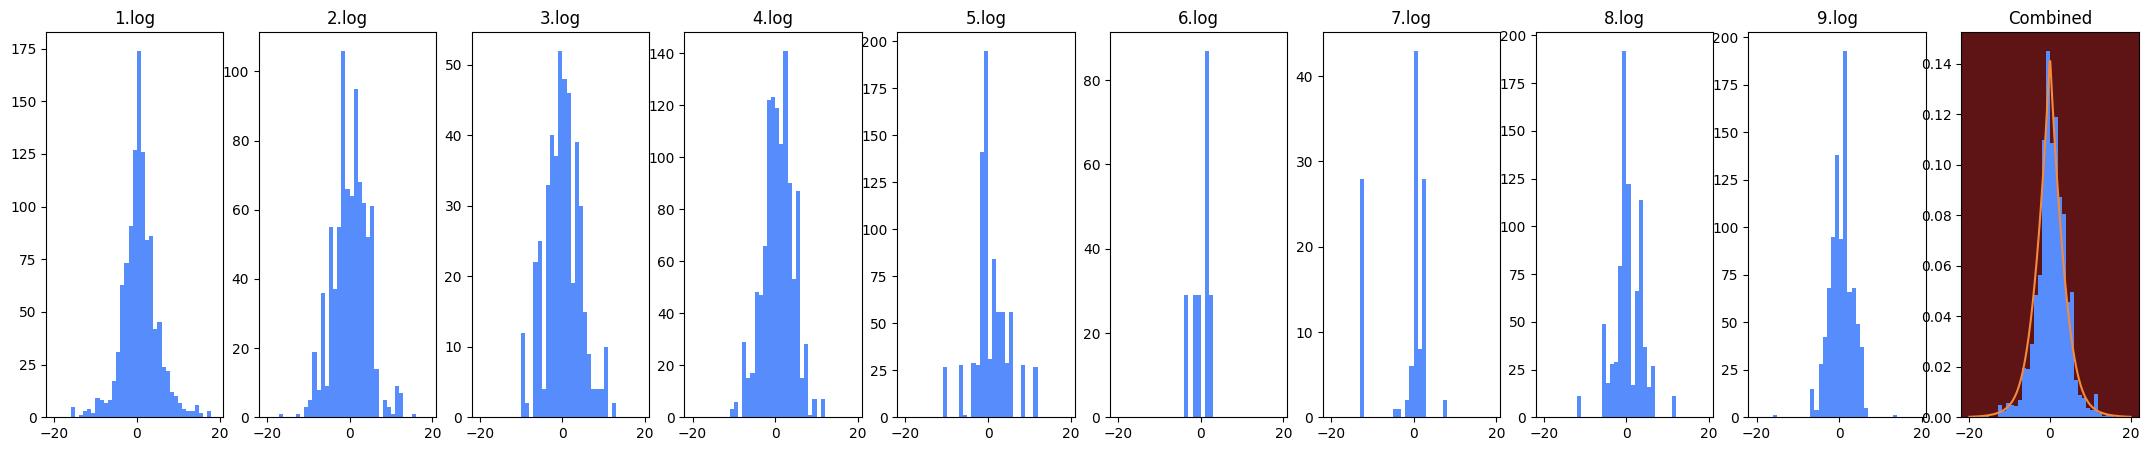

#### 165 to 195 Degrees

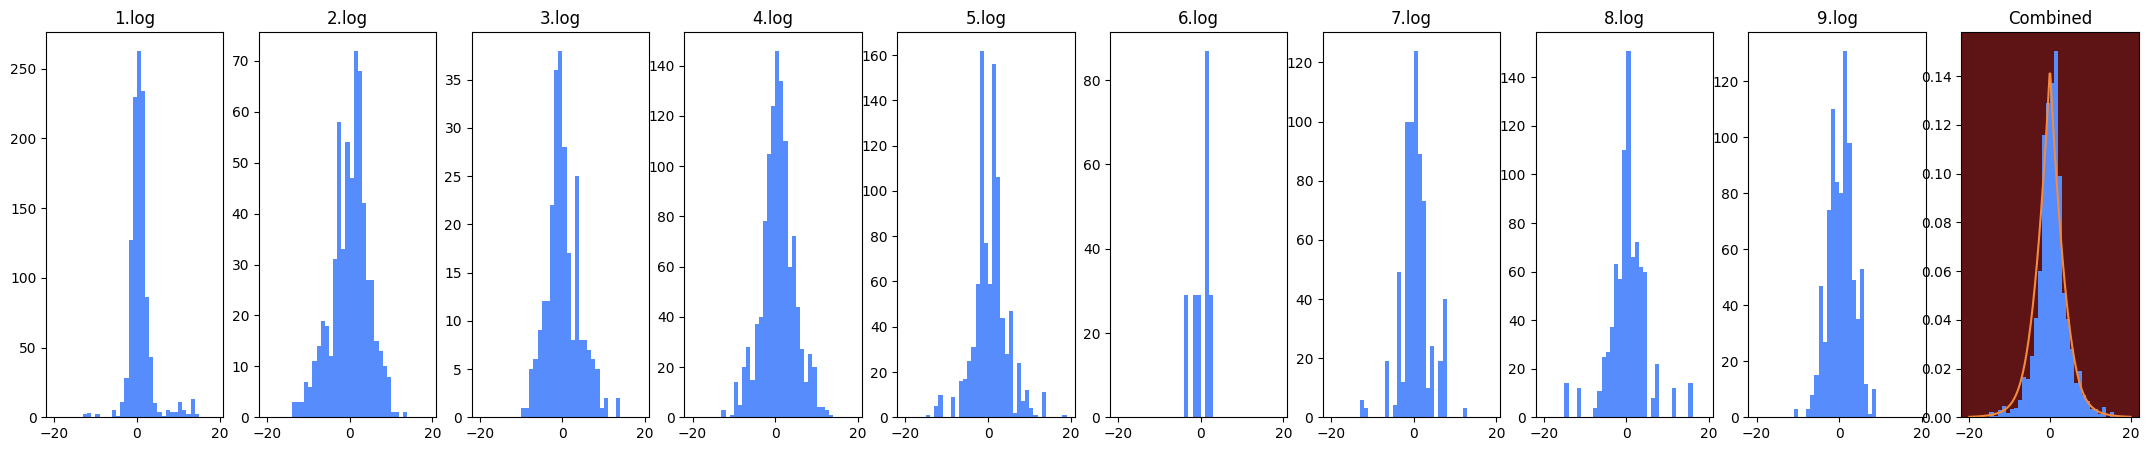

#### 195 to 225 Degrees

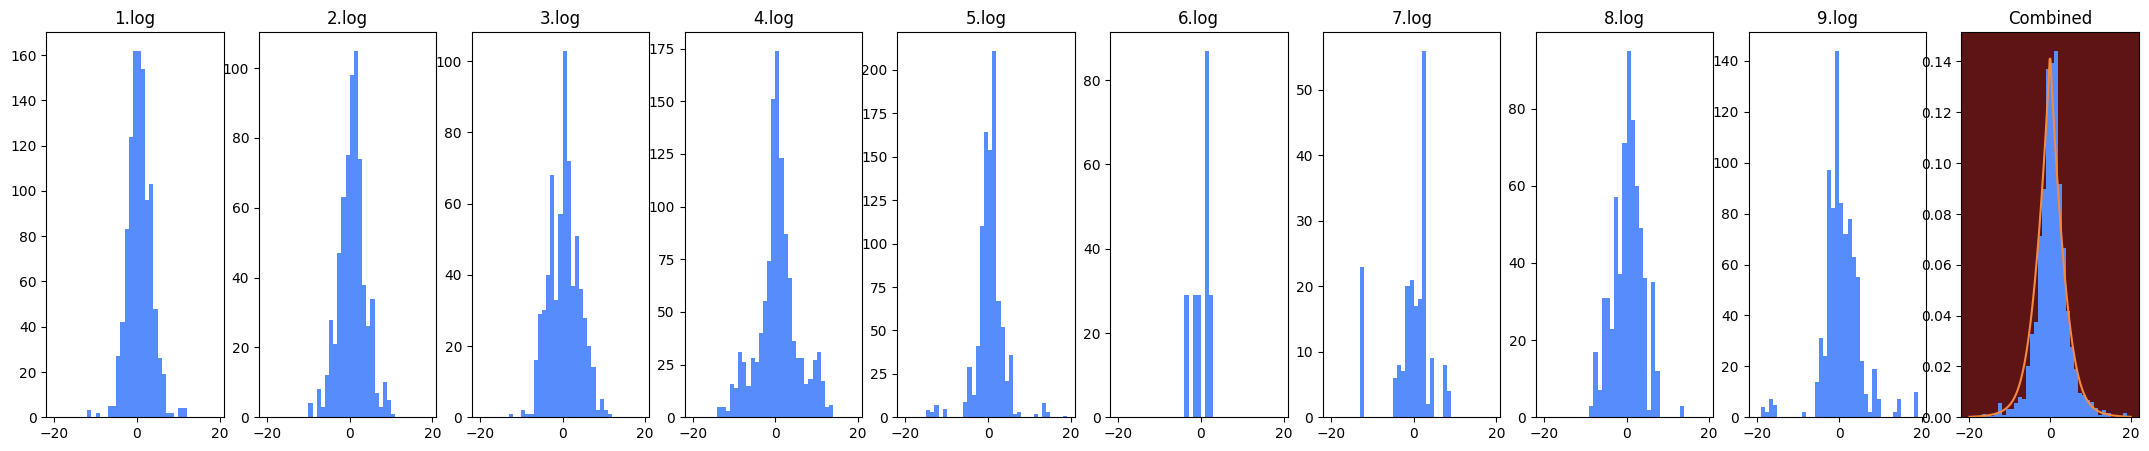

#### 225 to 255 Degrees

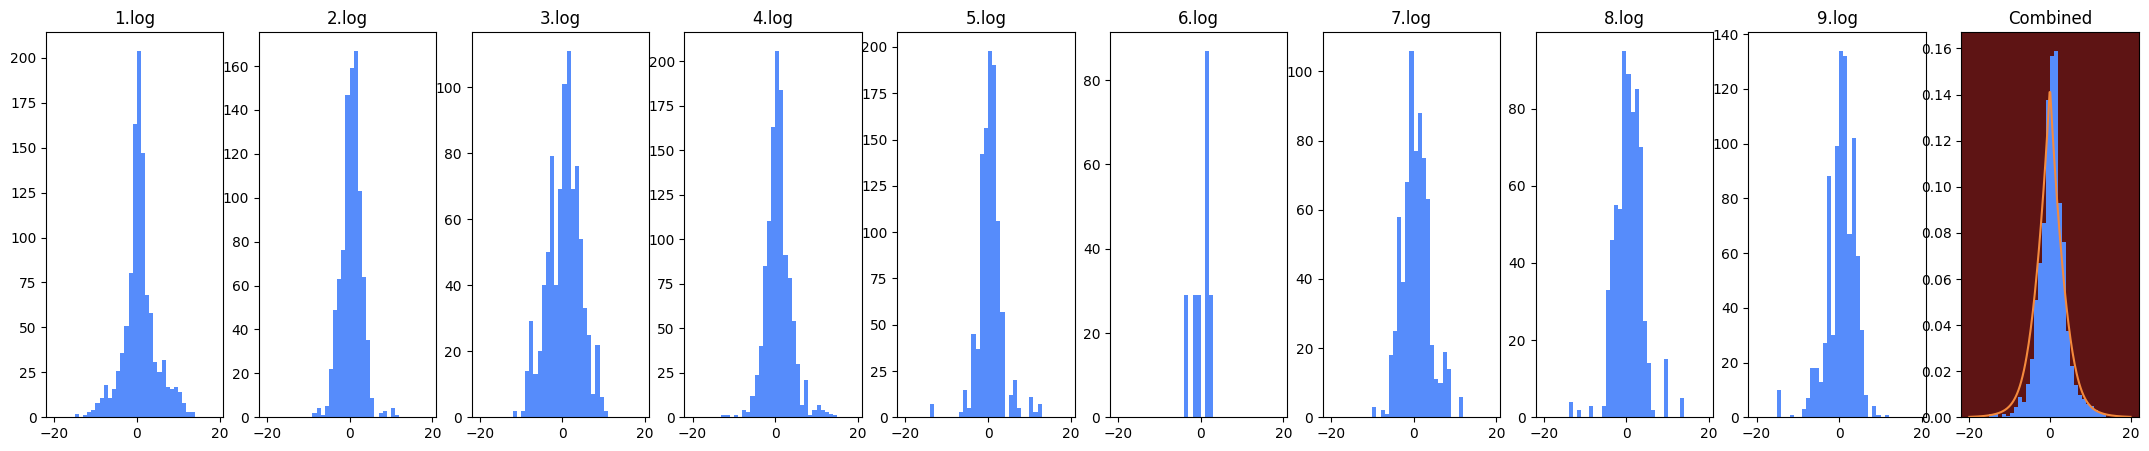

#### 255 to 285 Degrees

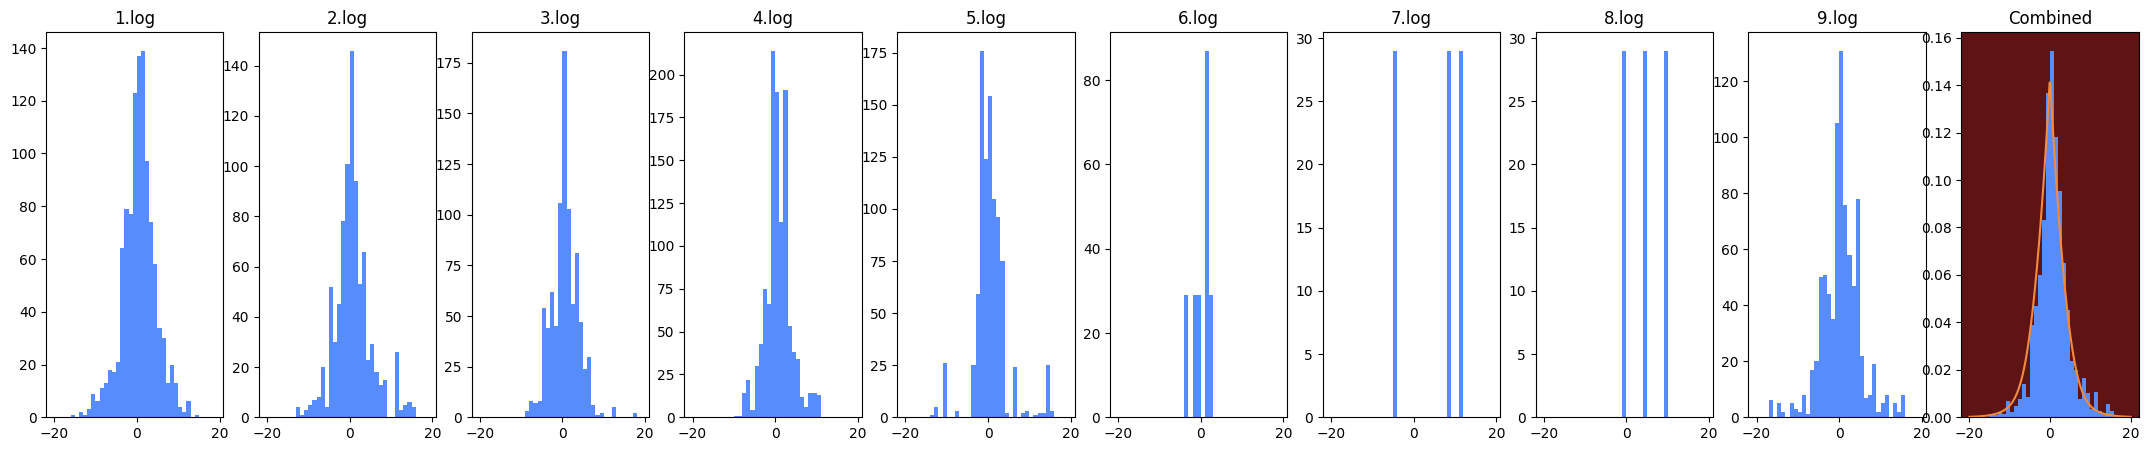

#### 285 to 315 Degrees

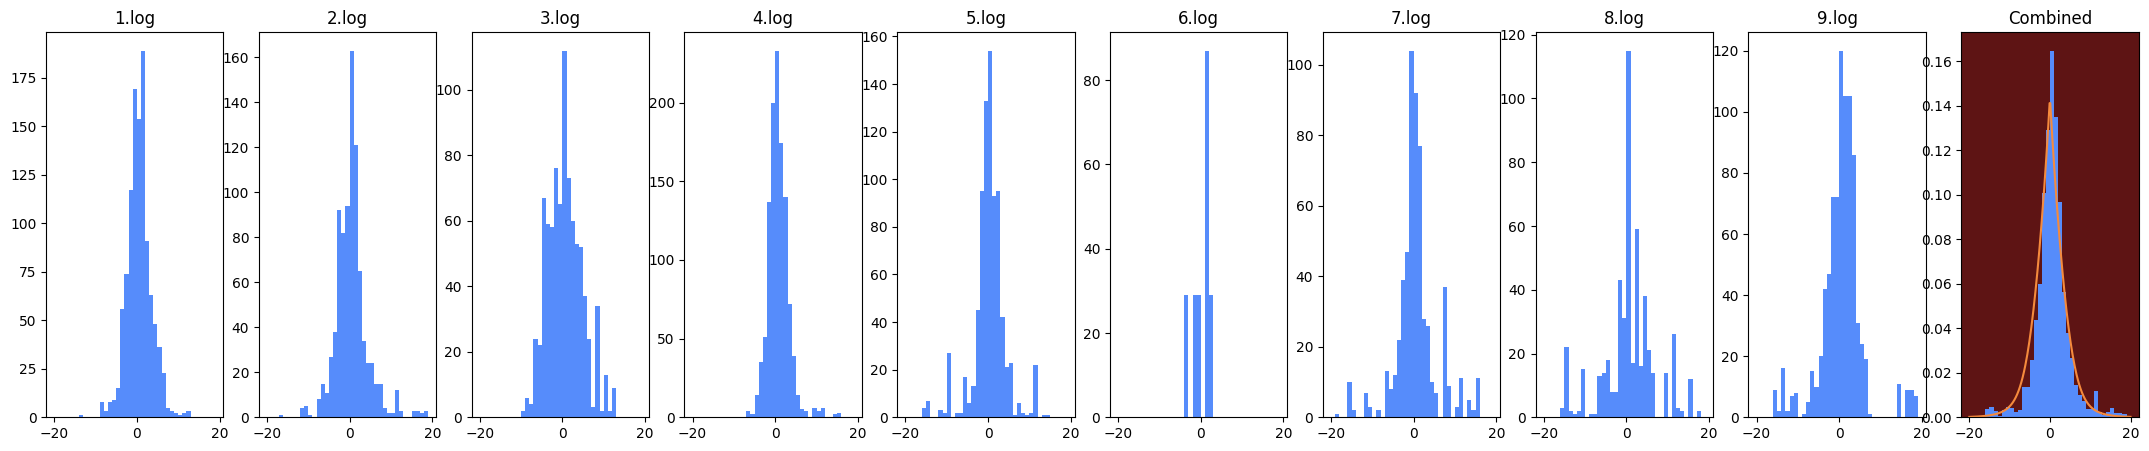

#### 315 to 345 Degrees

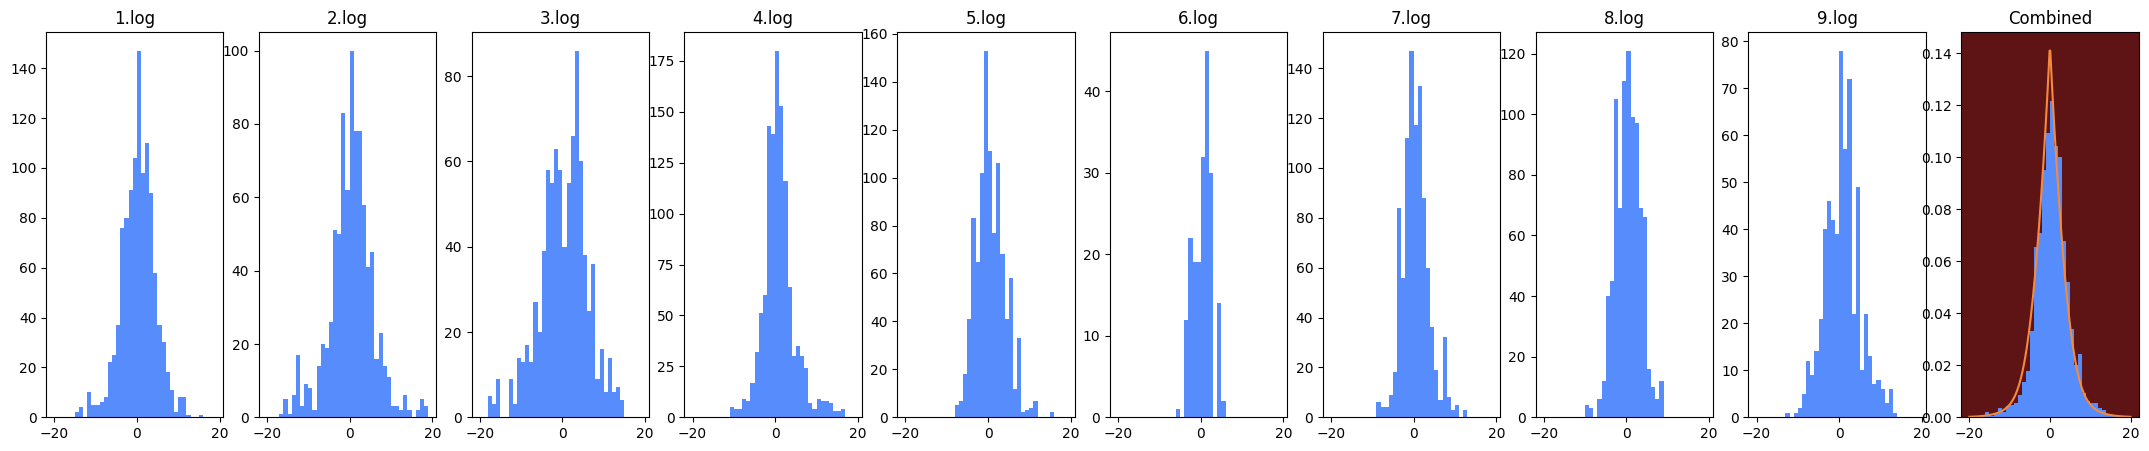

In [6]:
range_trial_rss_diffs_in_blocks(range_logs, 2)

### Five Packet Differences

The difference is taken between the current packet and the packet at the same gamma in five transmitter-rotations' time (approximately 10 seconds later). Examine the RSS in 30 degree blocks using histograms, and then all angles combined into one histogram.

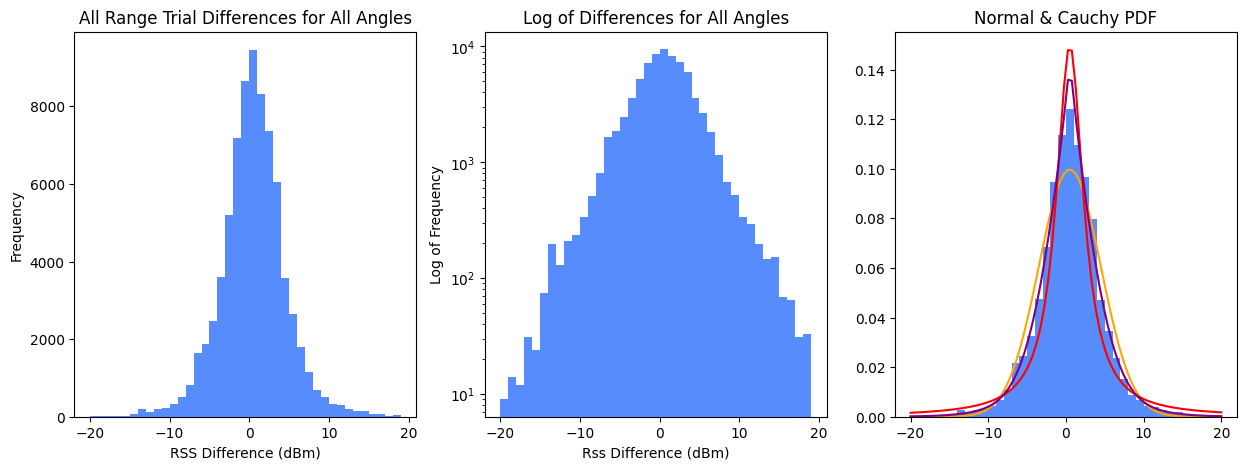

In [6]:
diffs_5 = combined_rss_at_gamma_analysis(range_logs, 5)

#### -15 to 15 Degrees

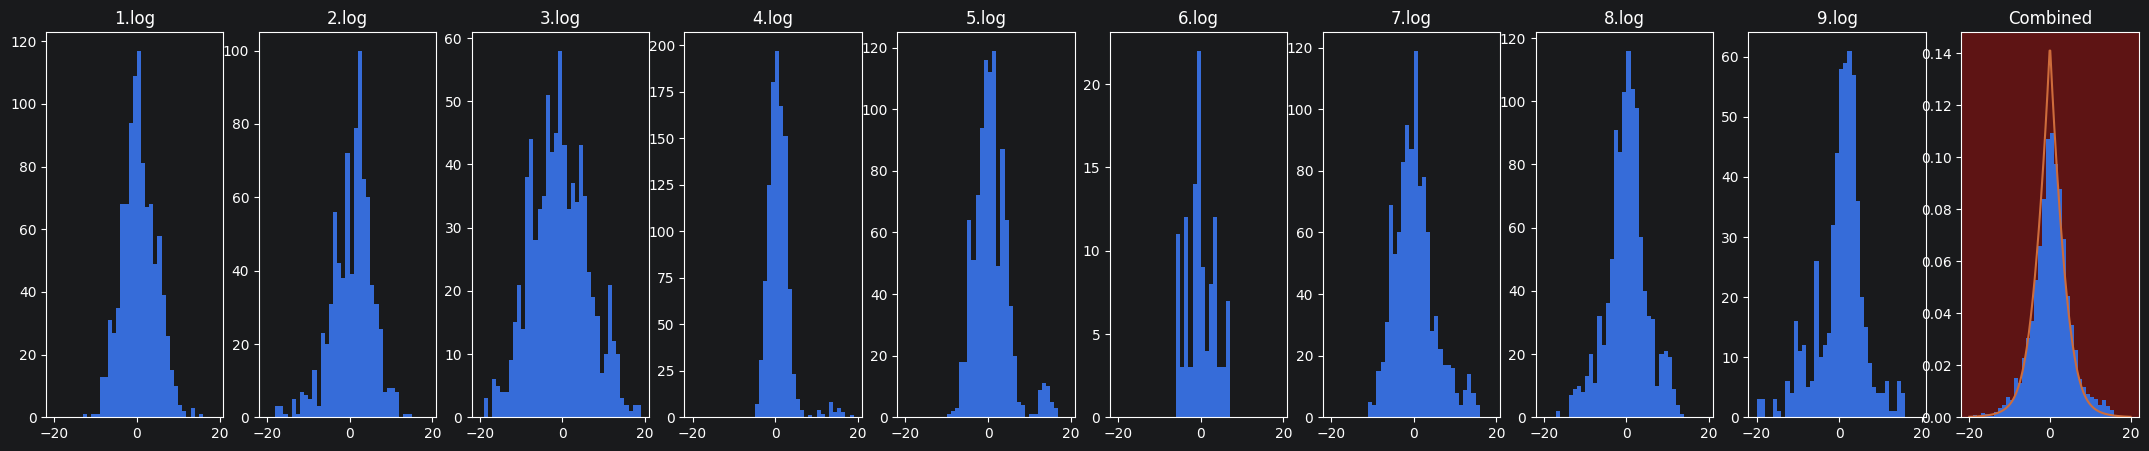

#### 15 to 45 Degrees

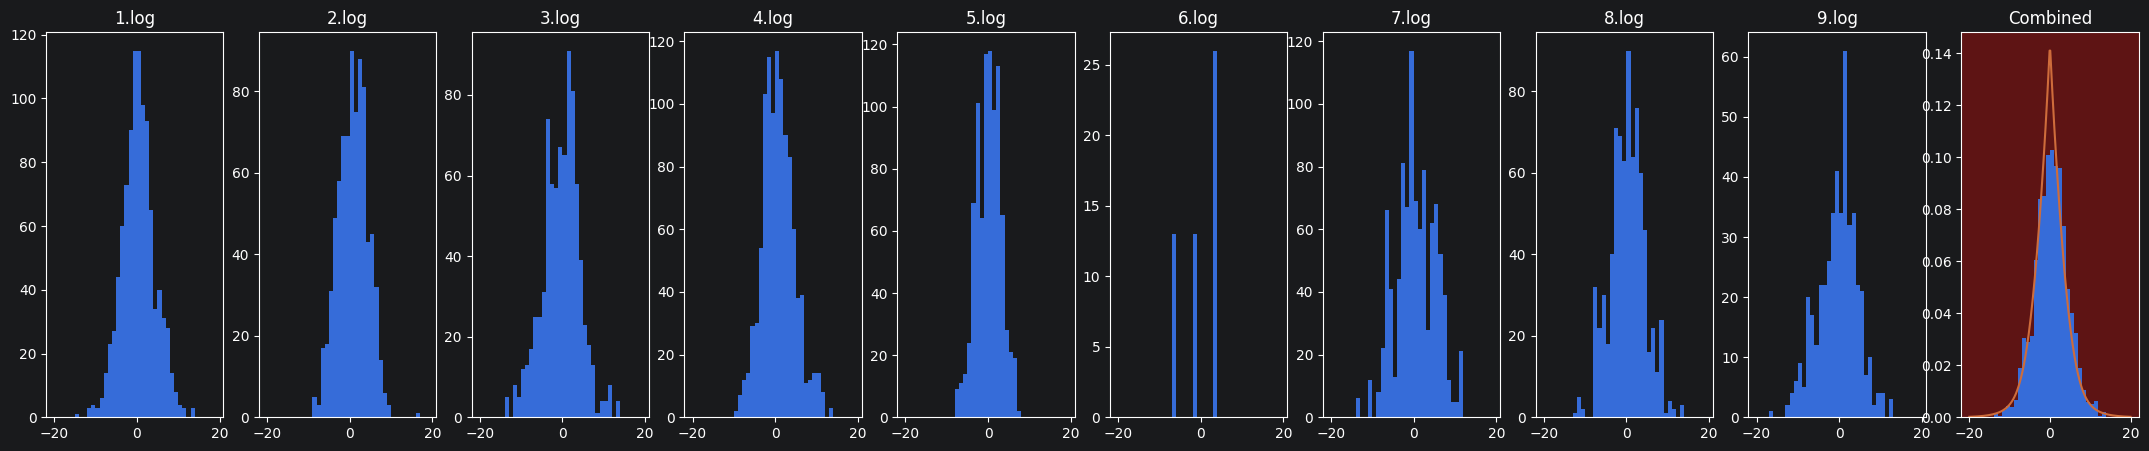

#### 45 to 75 Degrees

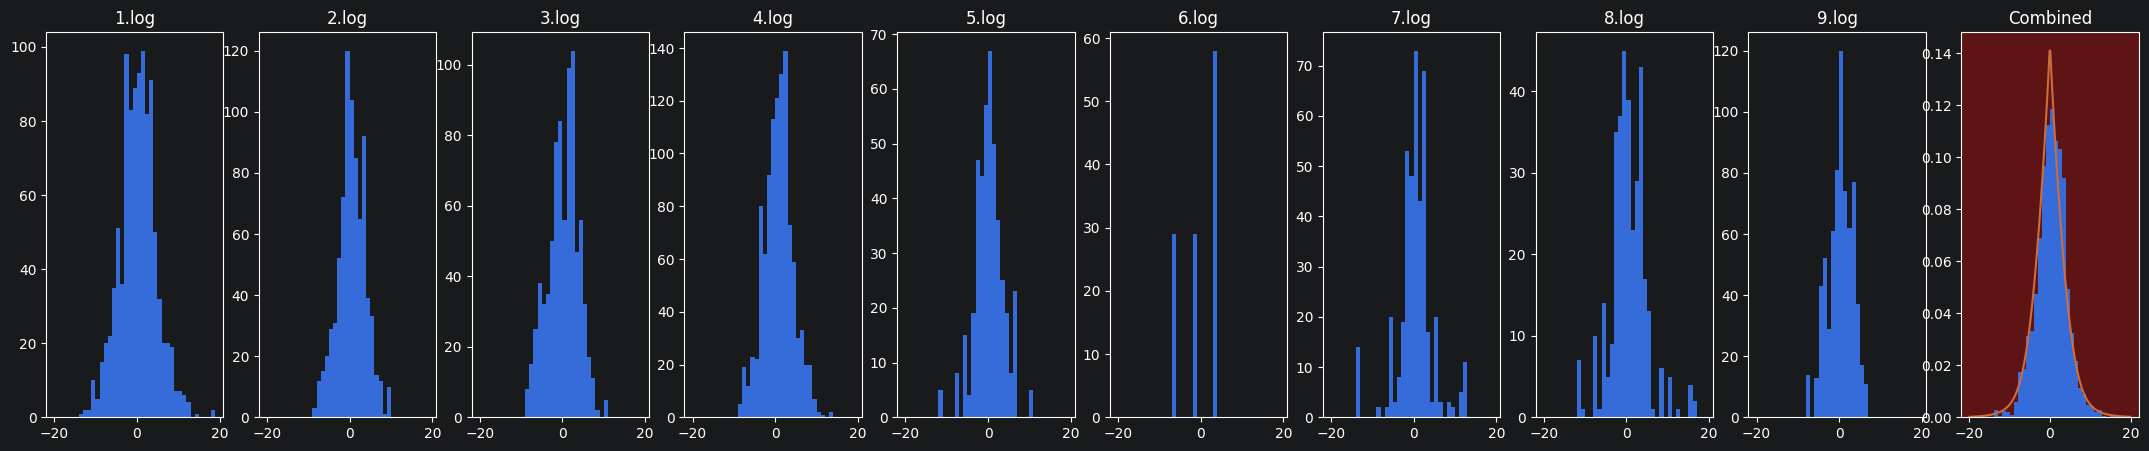

#### 75 to 105 Degrees

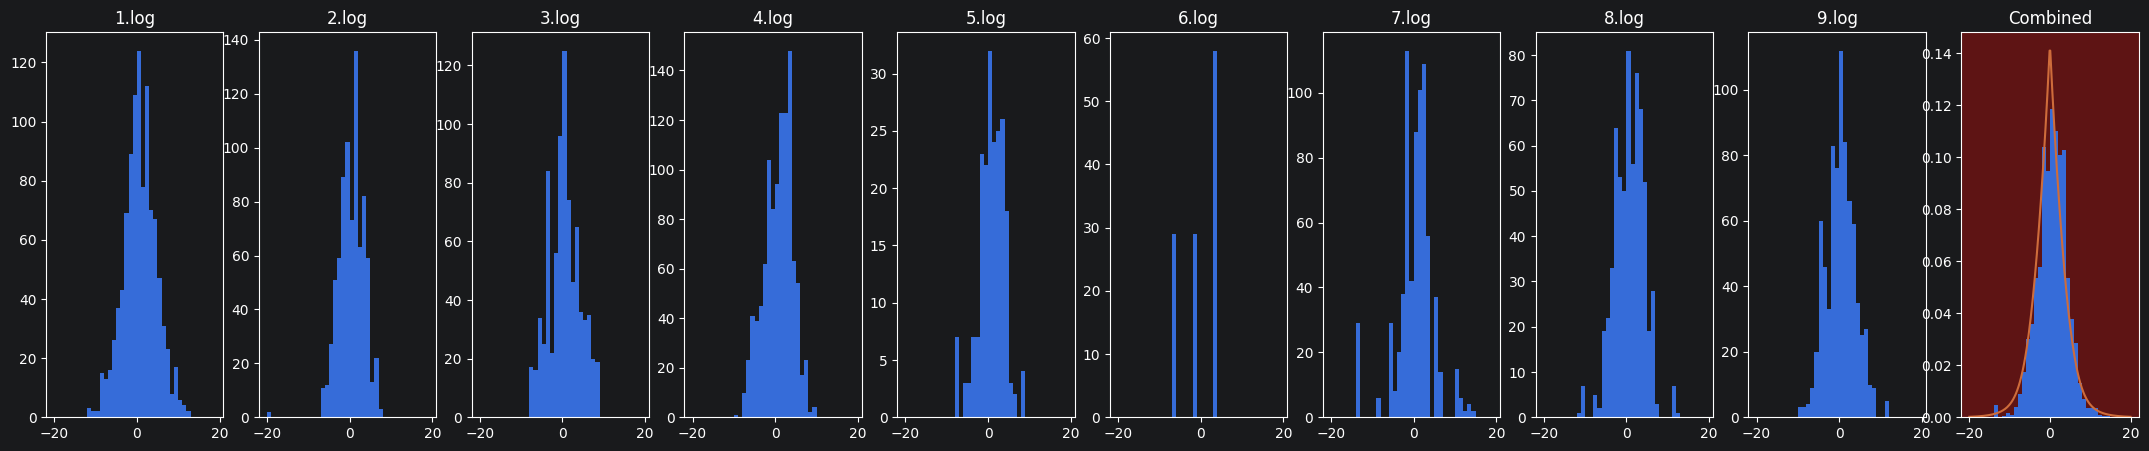

#### 105 to 135 Degrees

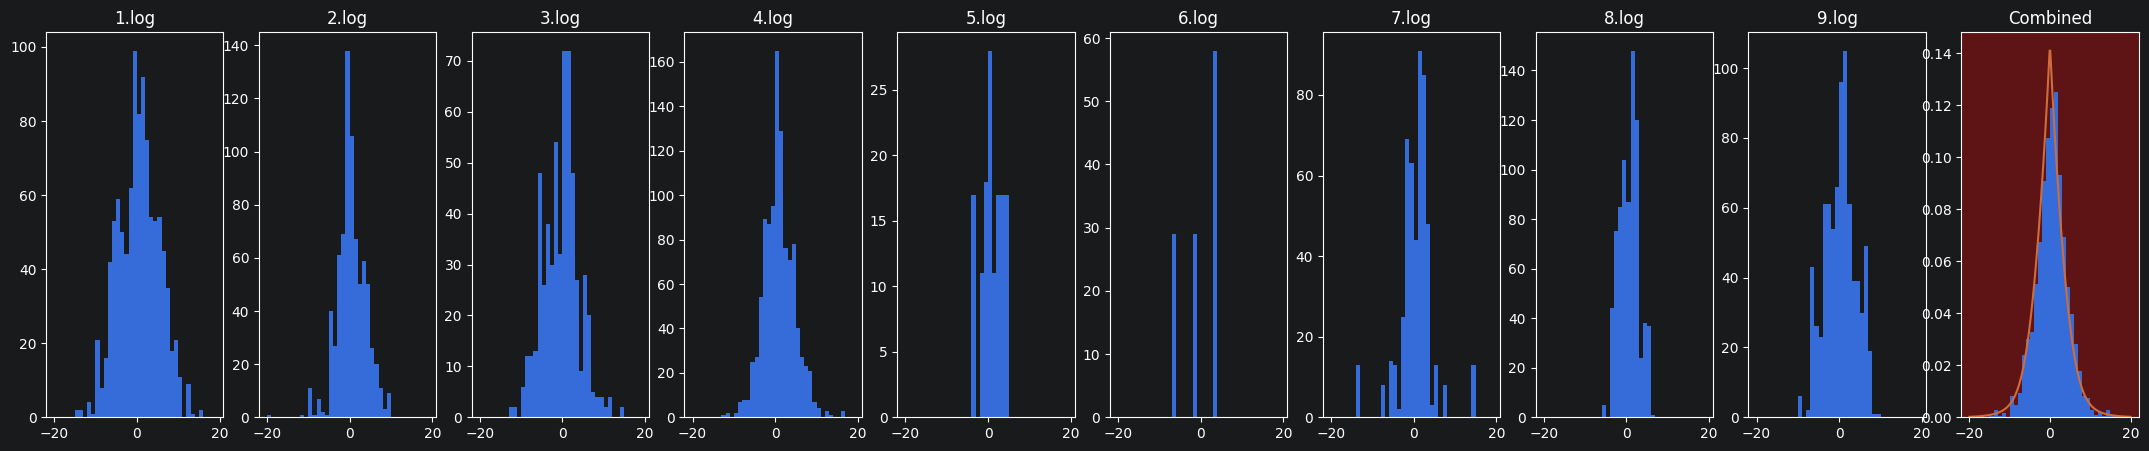

#### 135 to 165 Degrees

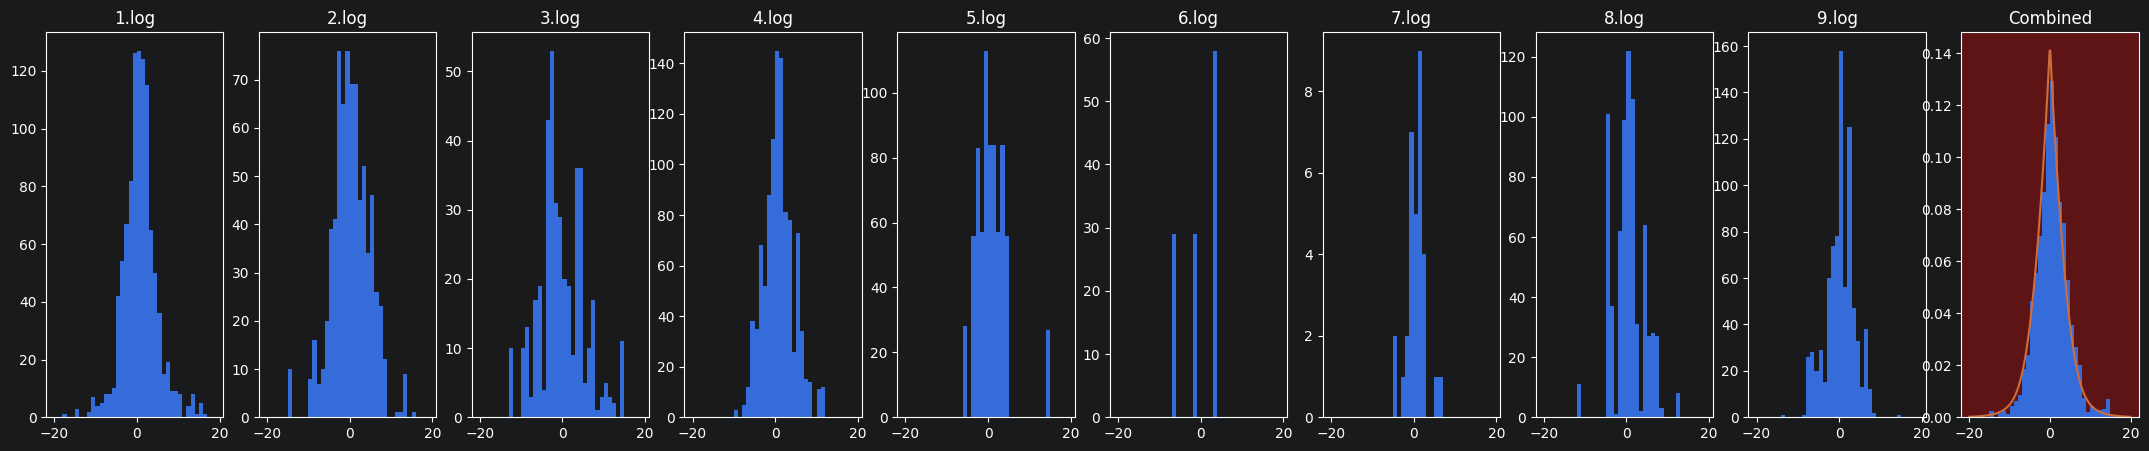

#### 165 to 195 Degrees

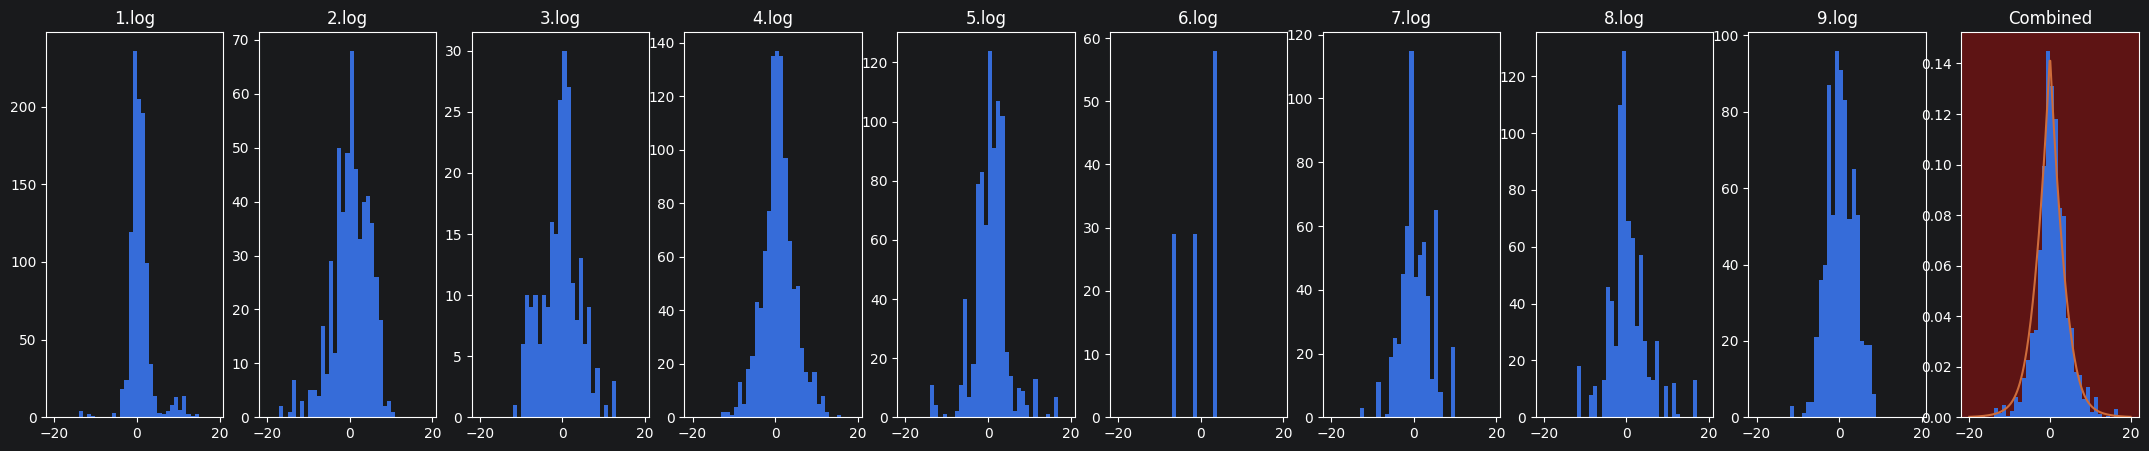

#### 195 to 225 Degrees

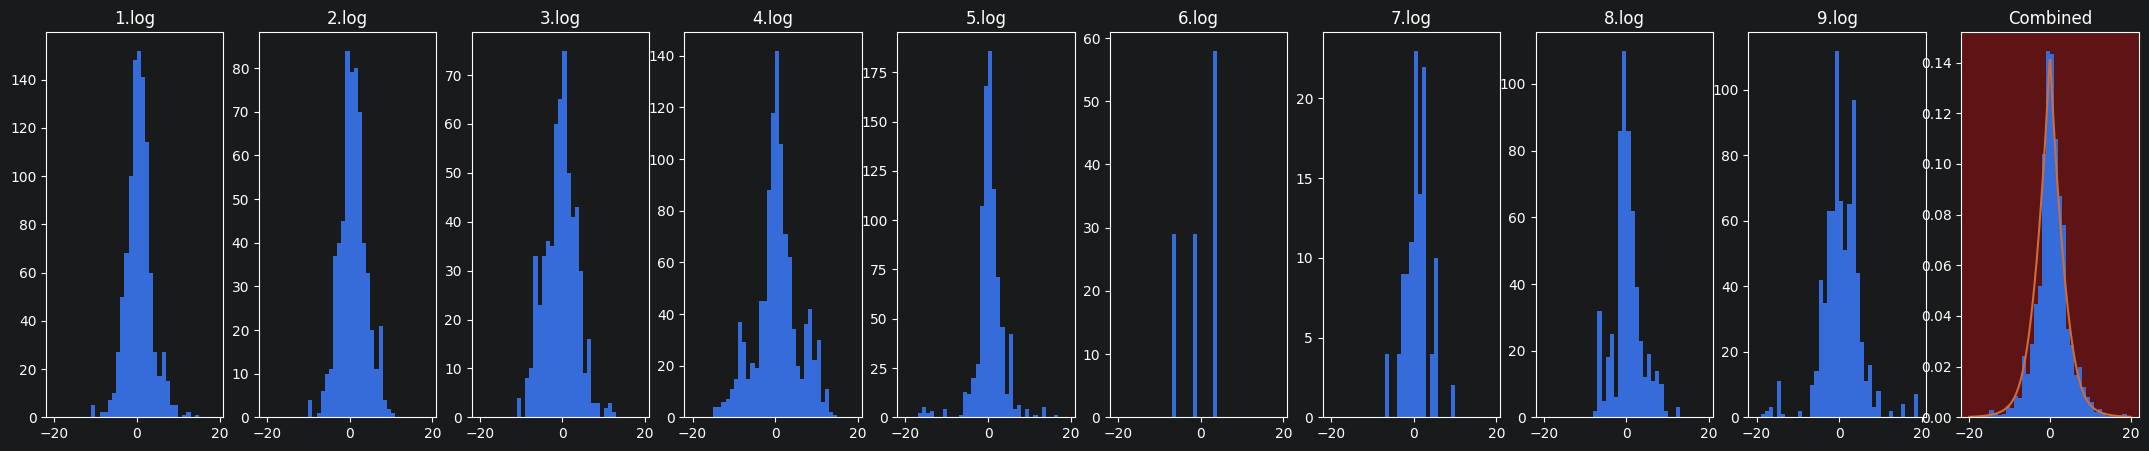

#### 225 to 255 Degrees

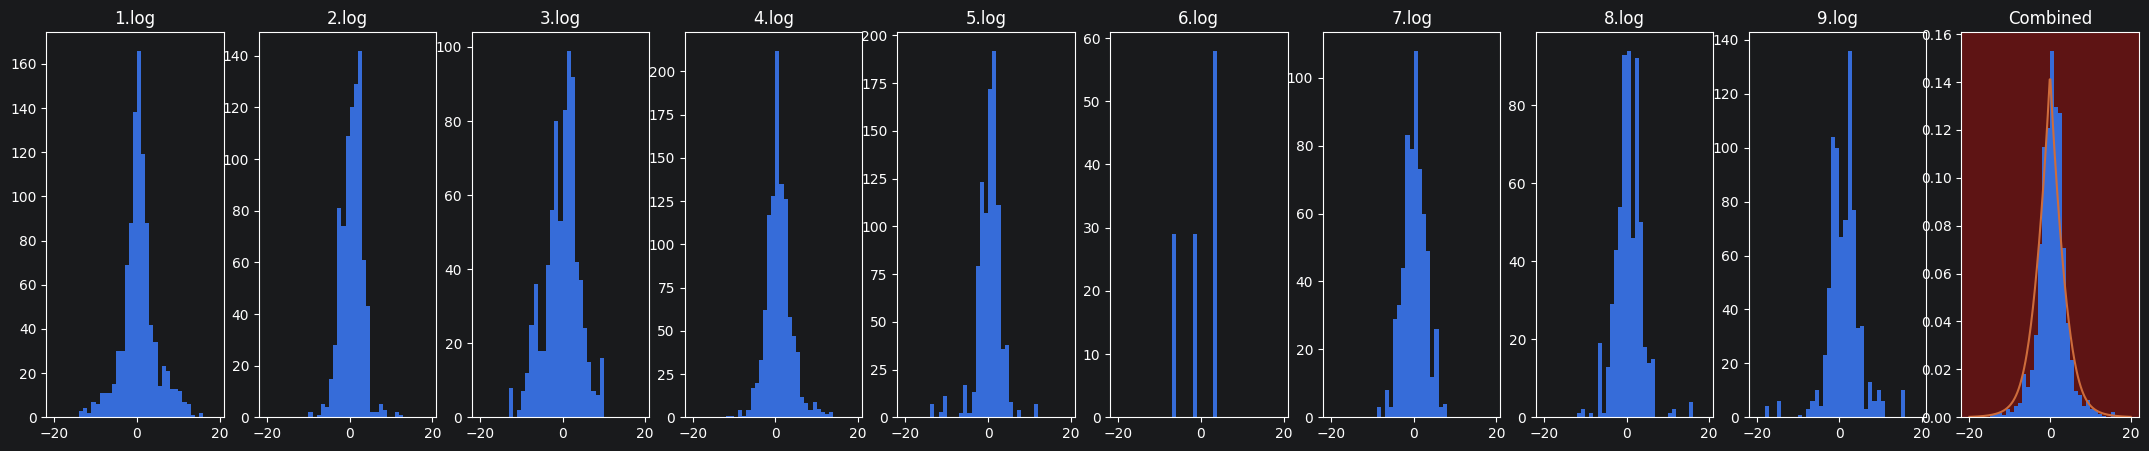

#### 255 to 285 Degrees

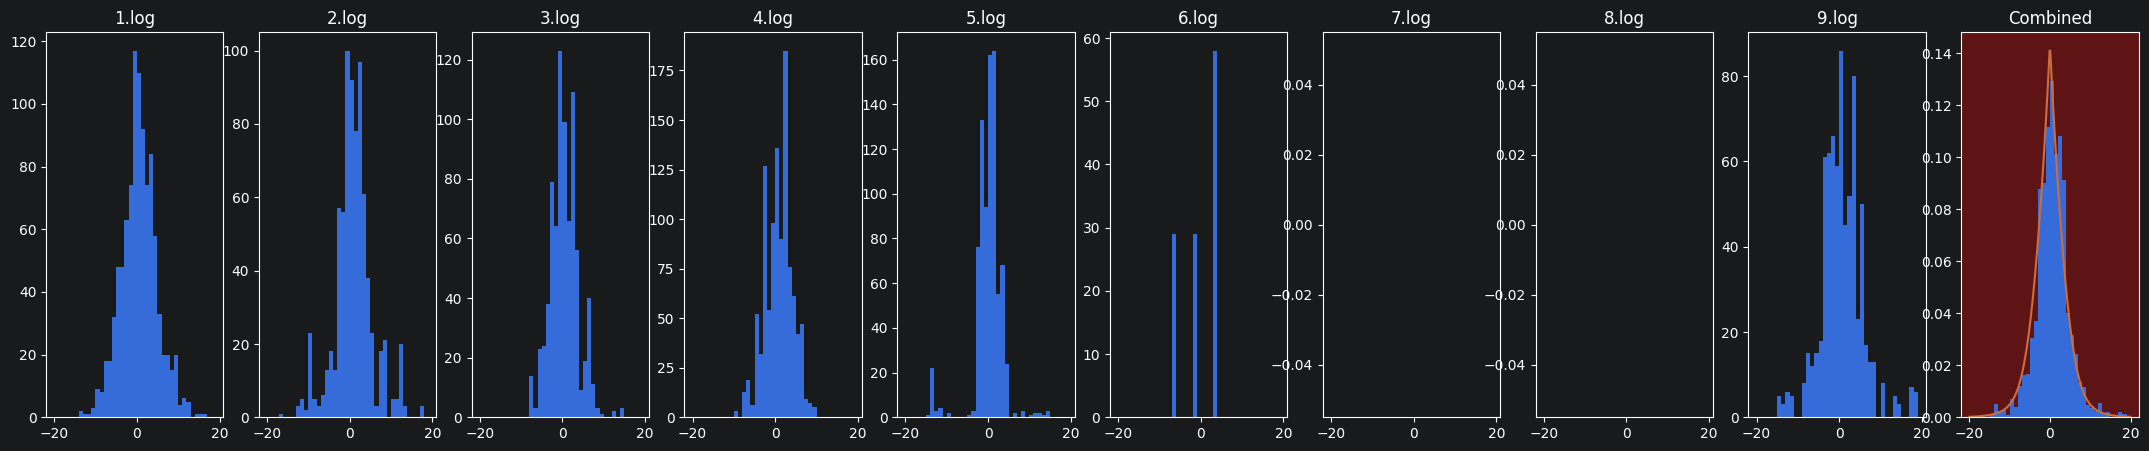

#### 285 to 315 Degrees

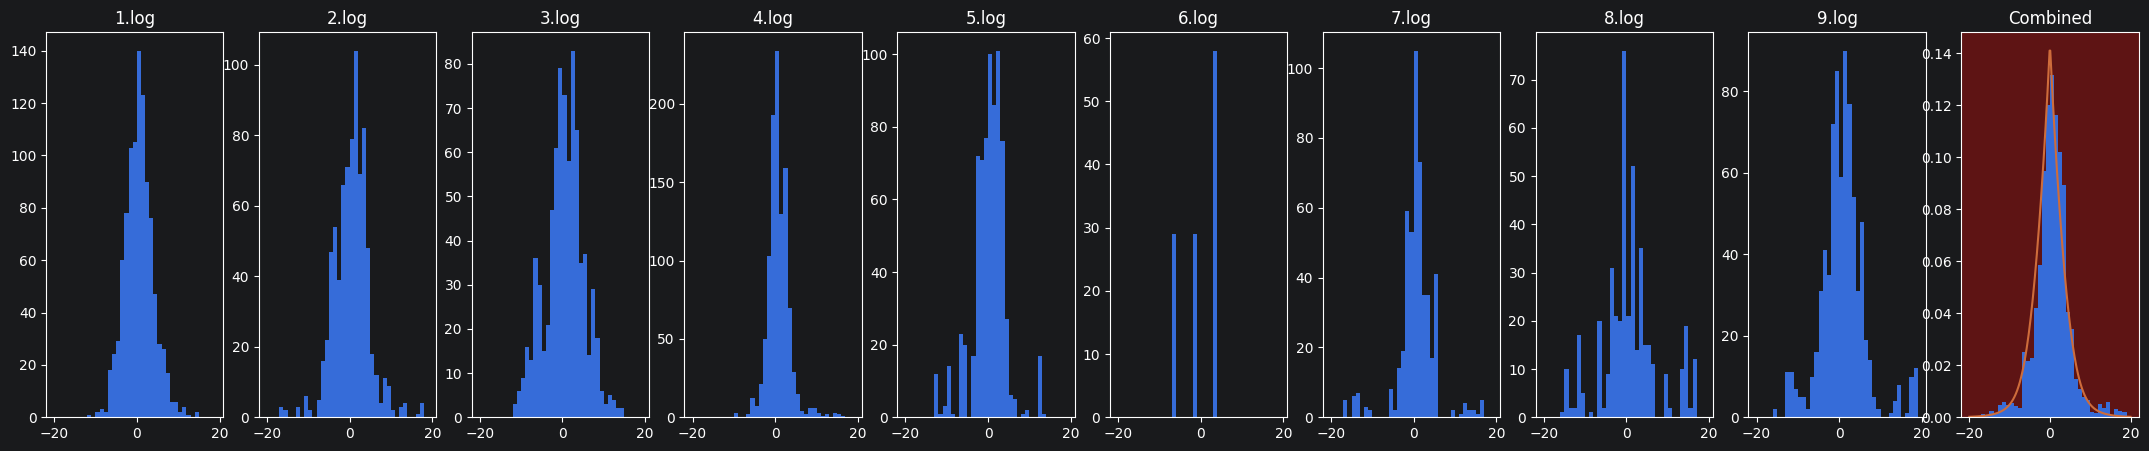

#### 315 to 345 Degrees

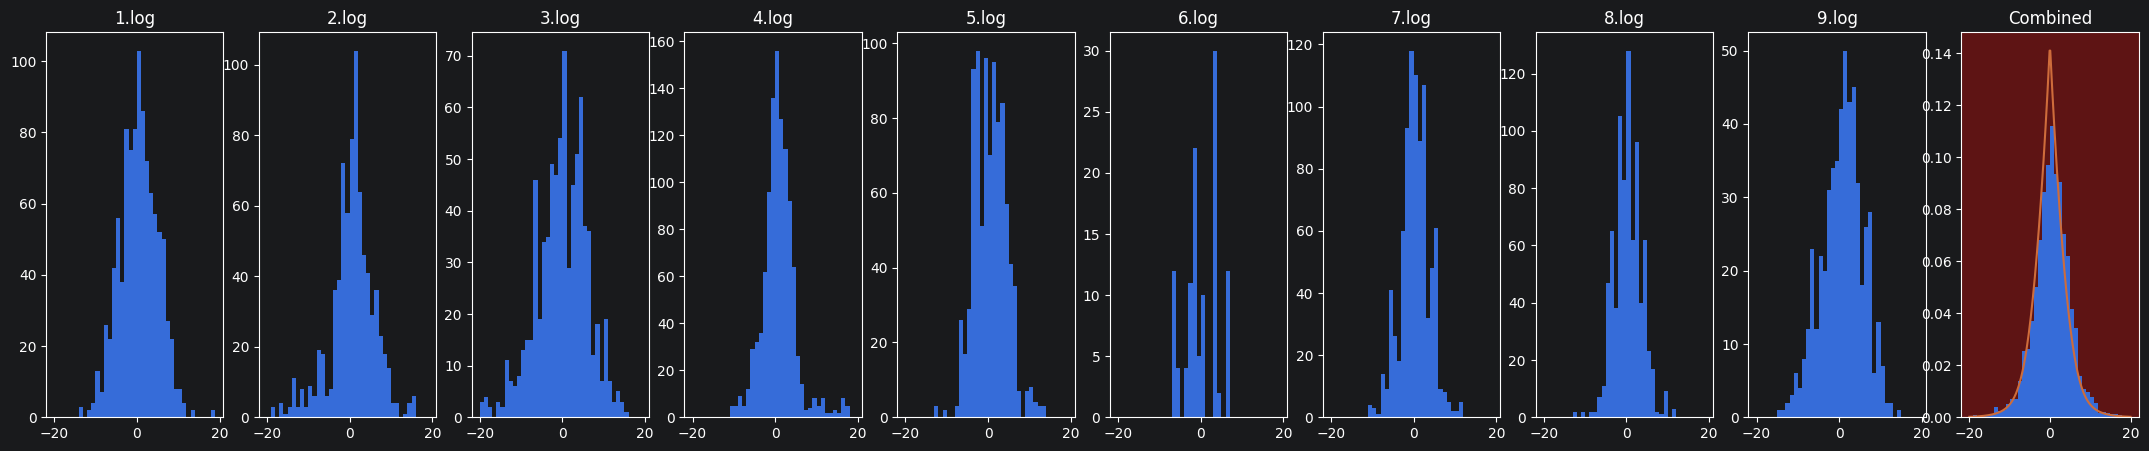

In [9]:
range_trial_rss_diffs_in_blocks(range_logs, 5)

### Ten Packet Differences

The difference is taken between the current packet and the packet at the same gamma in ten transmitter-rotations' time (approximately 20 seconds later). Examine the RSS in 30 degree blocks using histograms, and then all angles combined into one histogram.

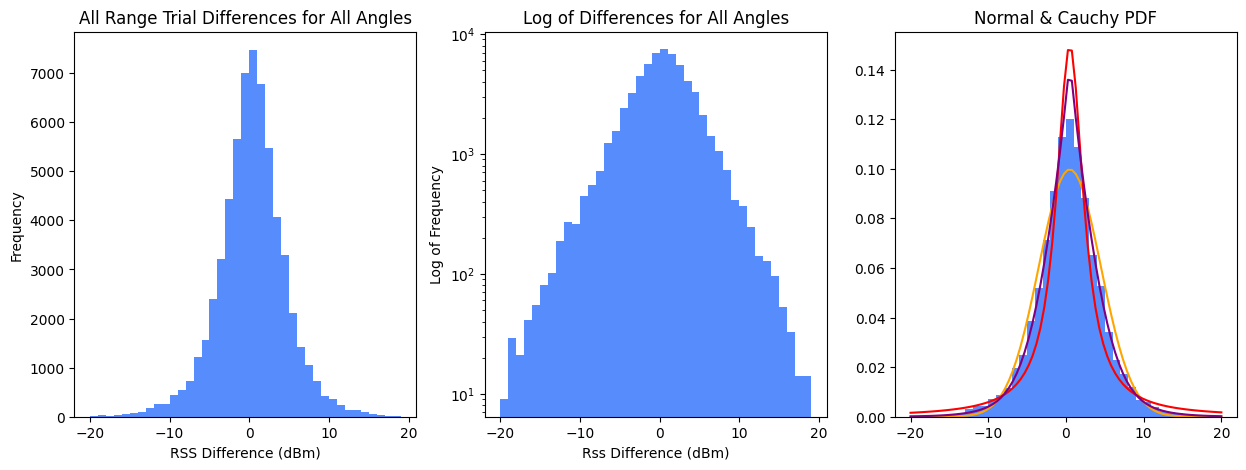

In [7]:
diffs_10 = combined_rss_at_gamma_analysis(range_logs, 10)

#### -15 to 15 Degrees

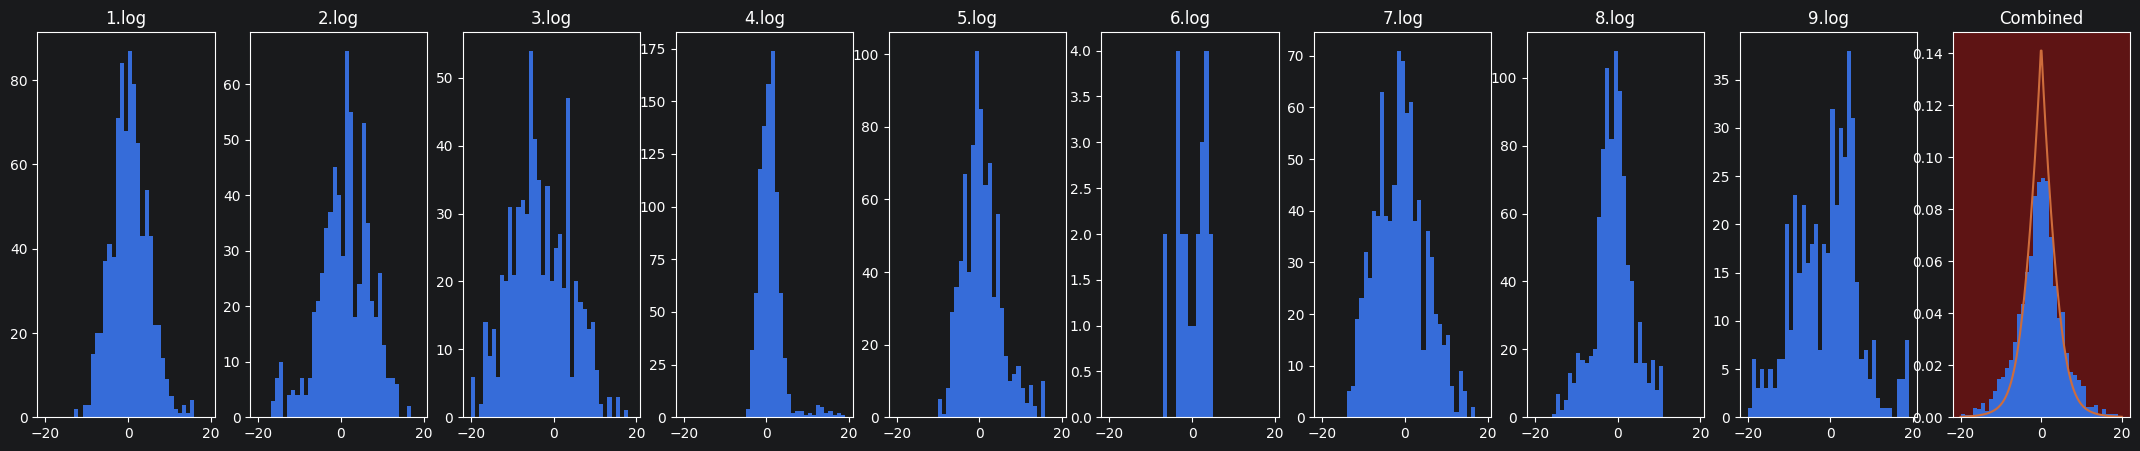

#### 15 to 45 Degrees

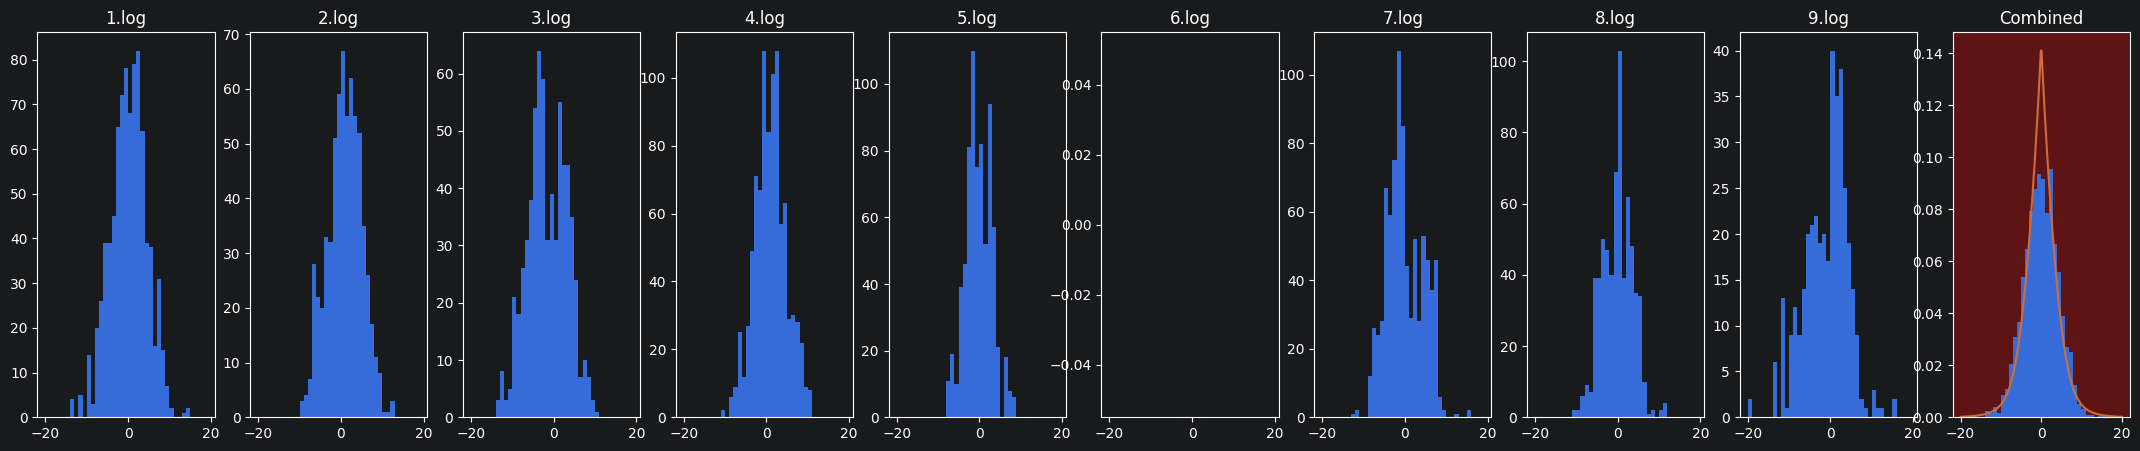

#### 45 to 75 Degrees

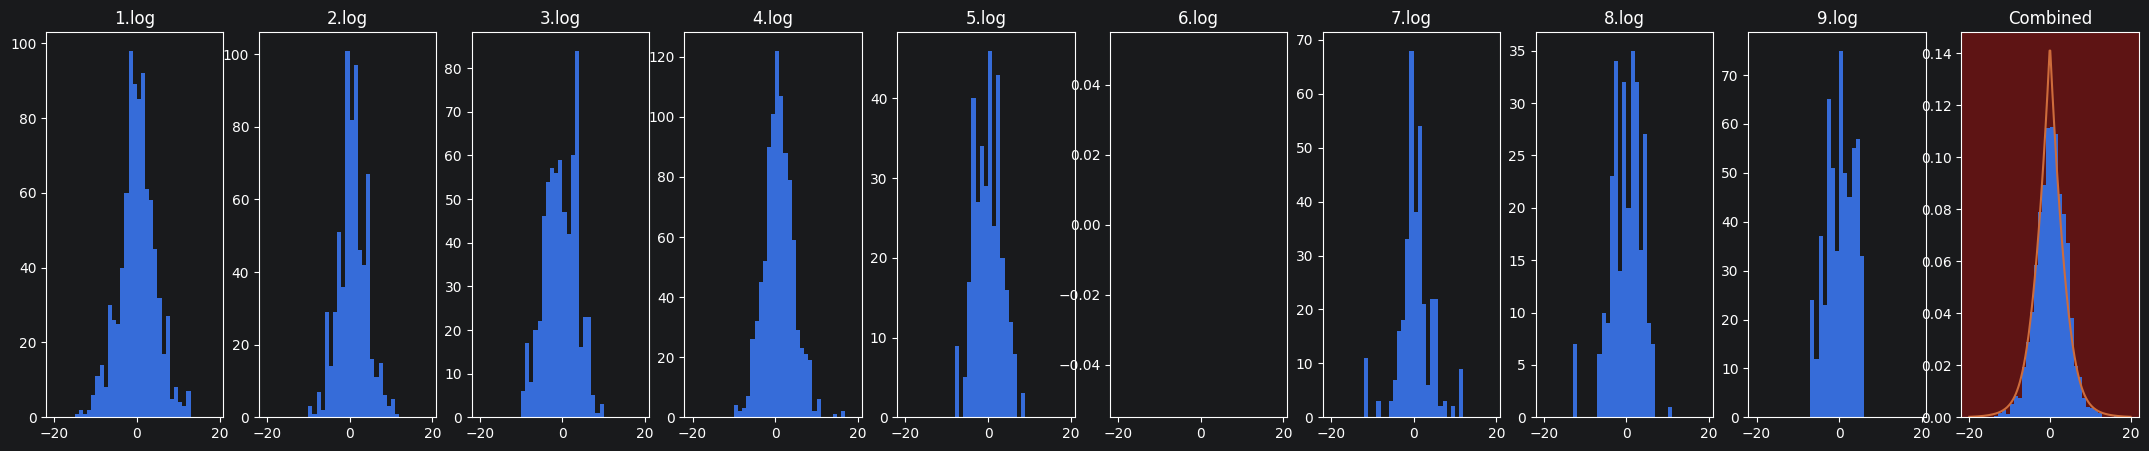

#### 75 to 105 Degrees

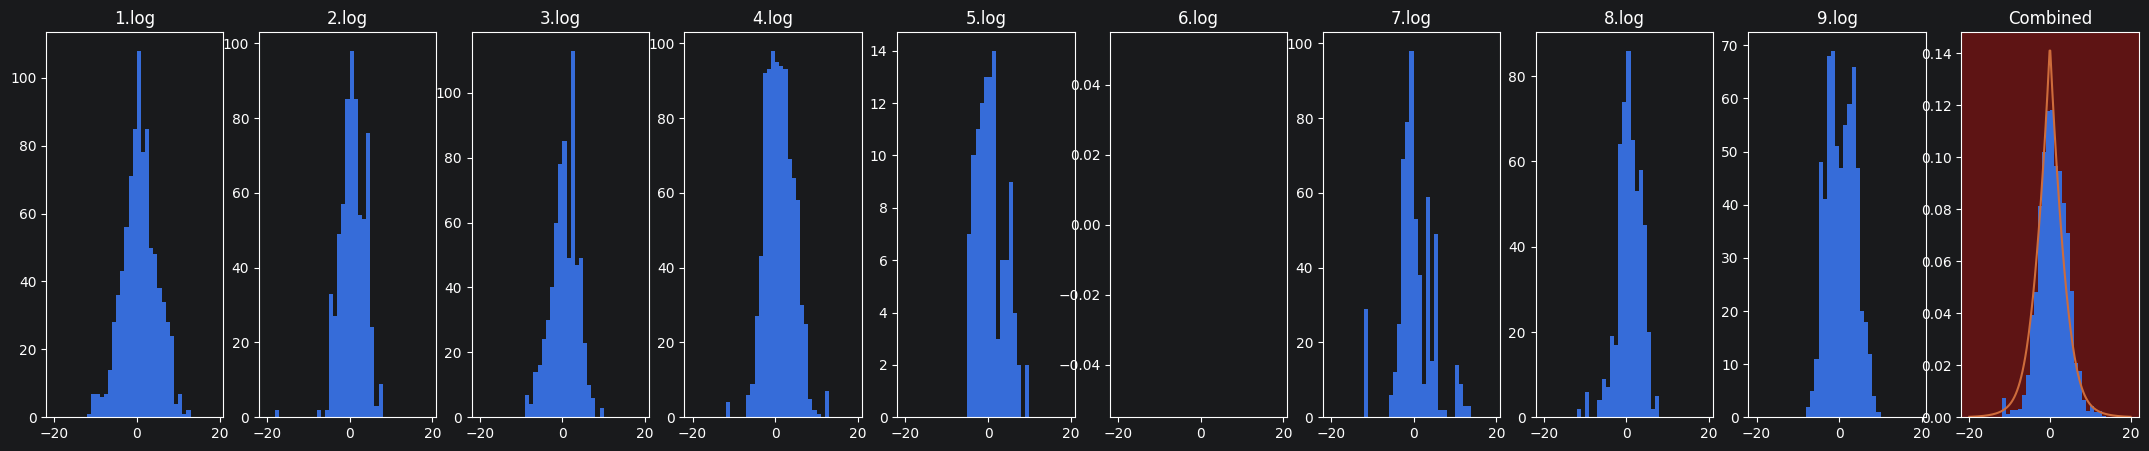

#### 105 to 135 Degrees

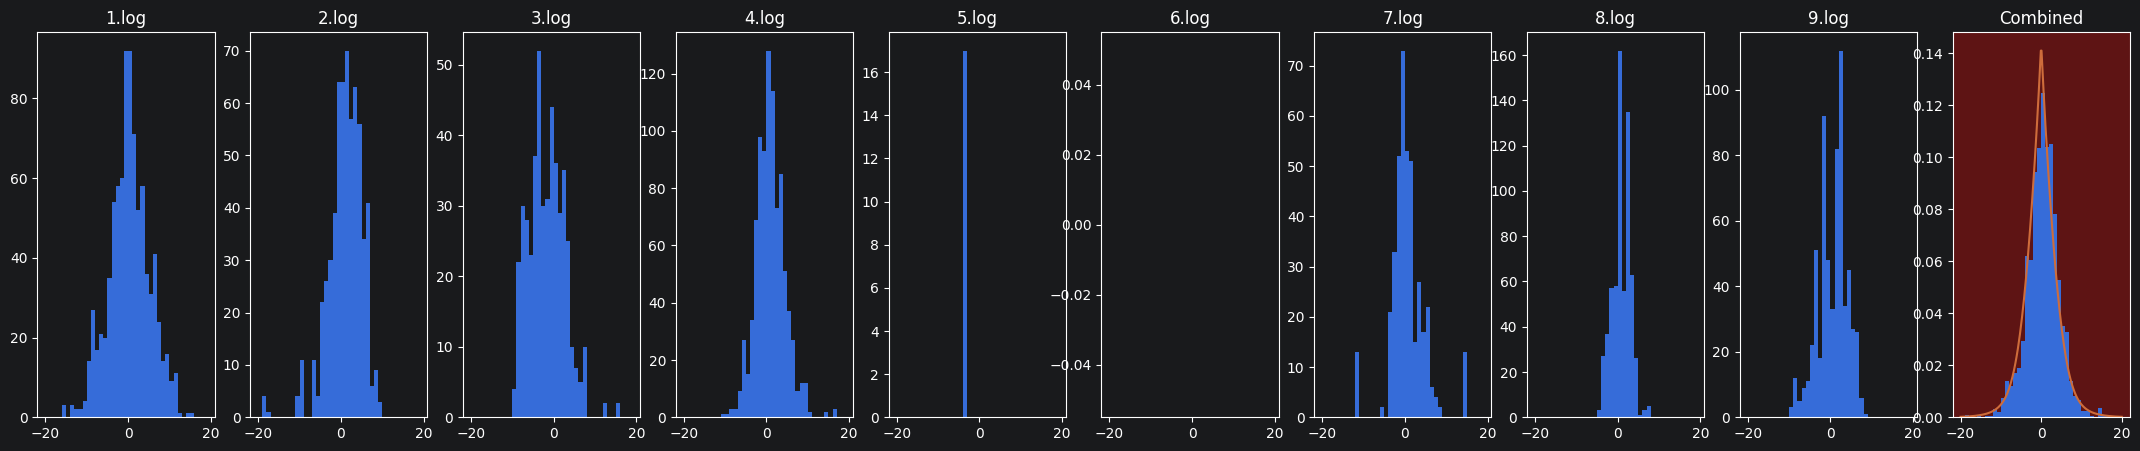

#### 135 to 165 Degrees

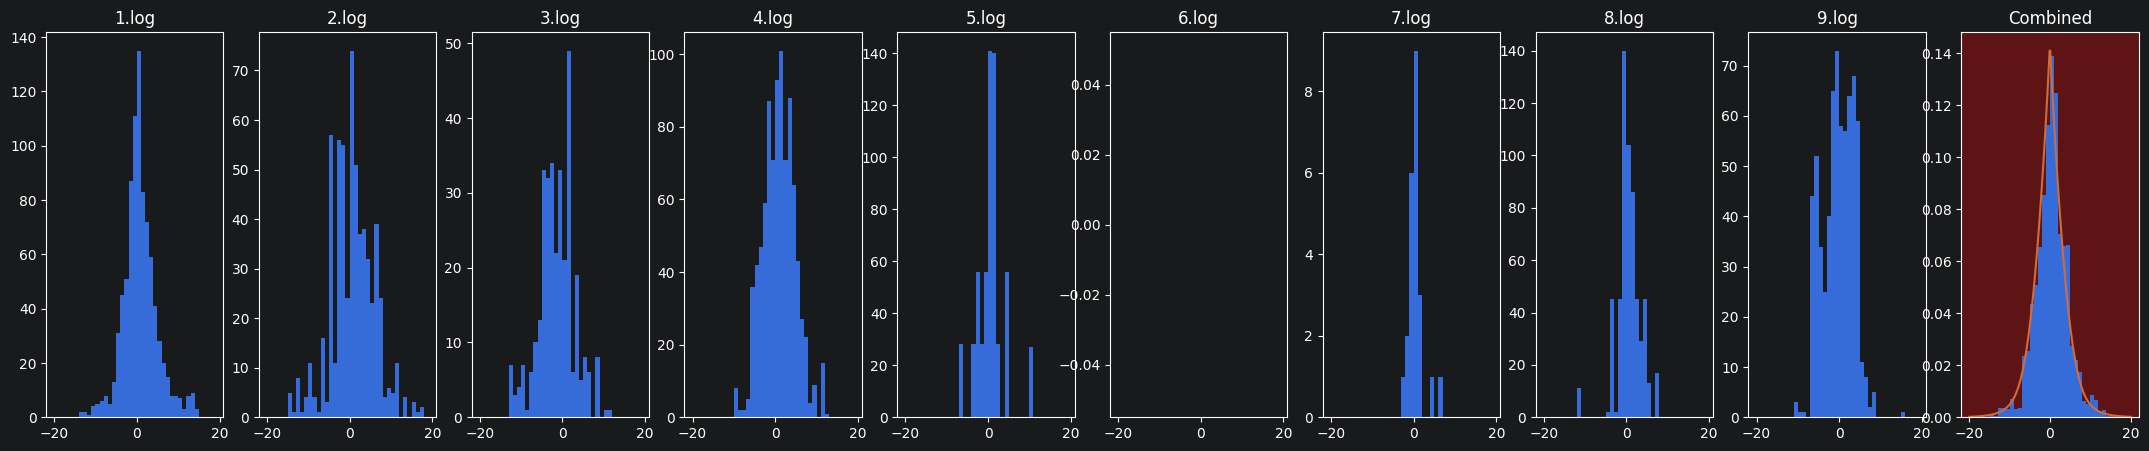

#### 165 to 195 Degrees

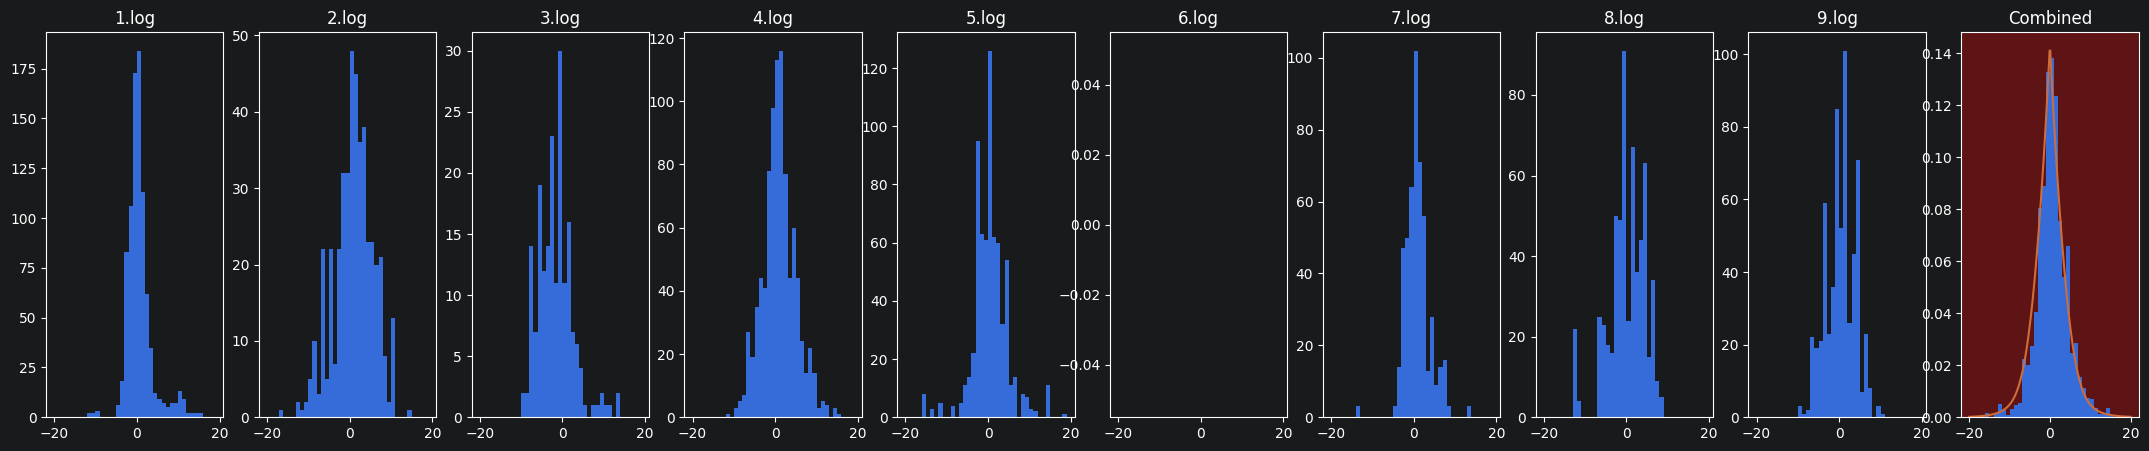

#### 195 to 225 Degrees

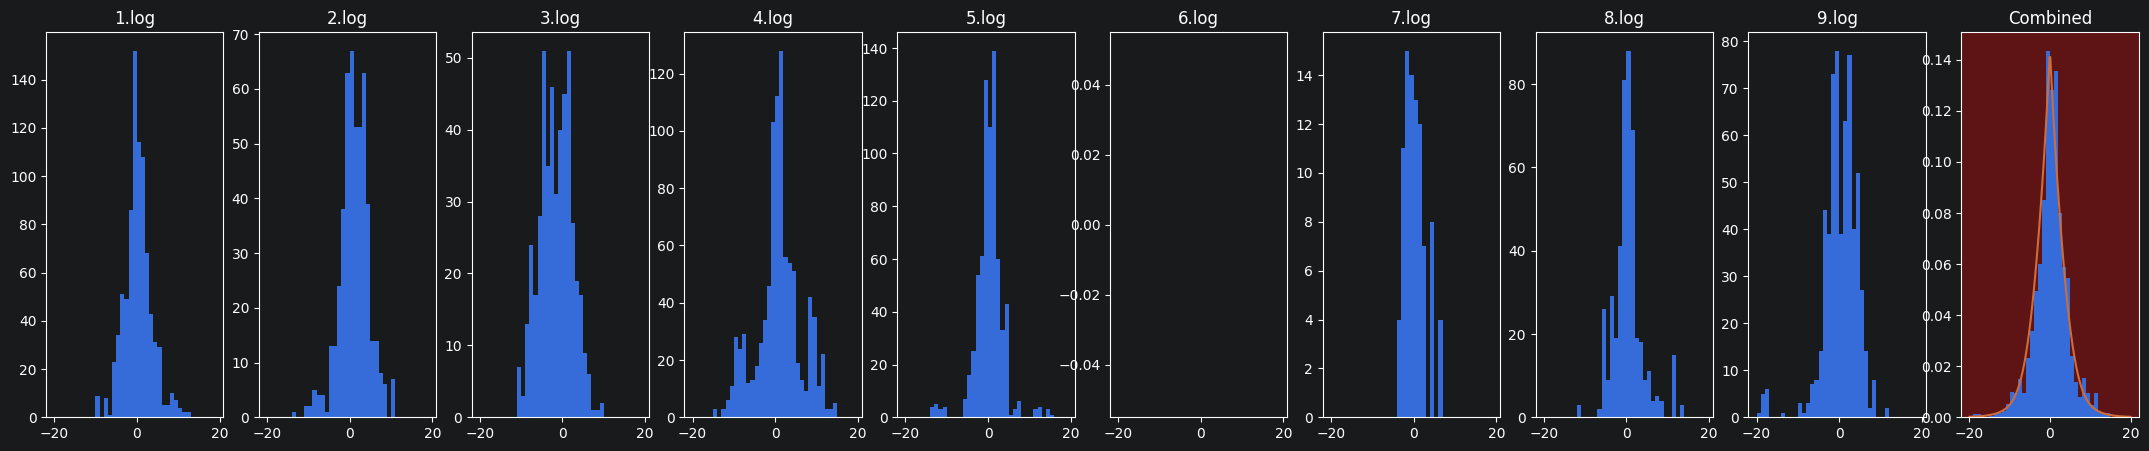

#### 225 to 255 Degrees

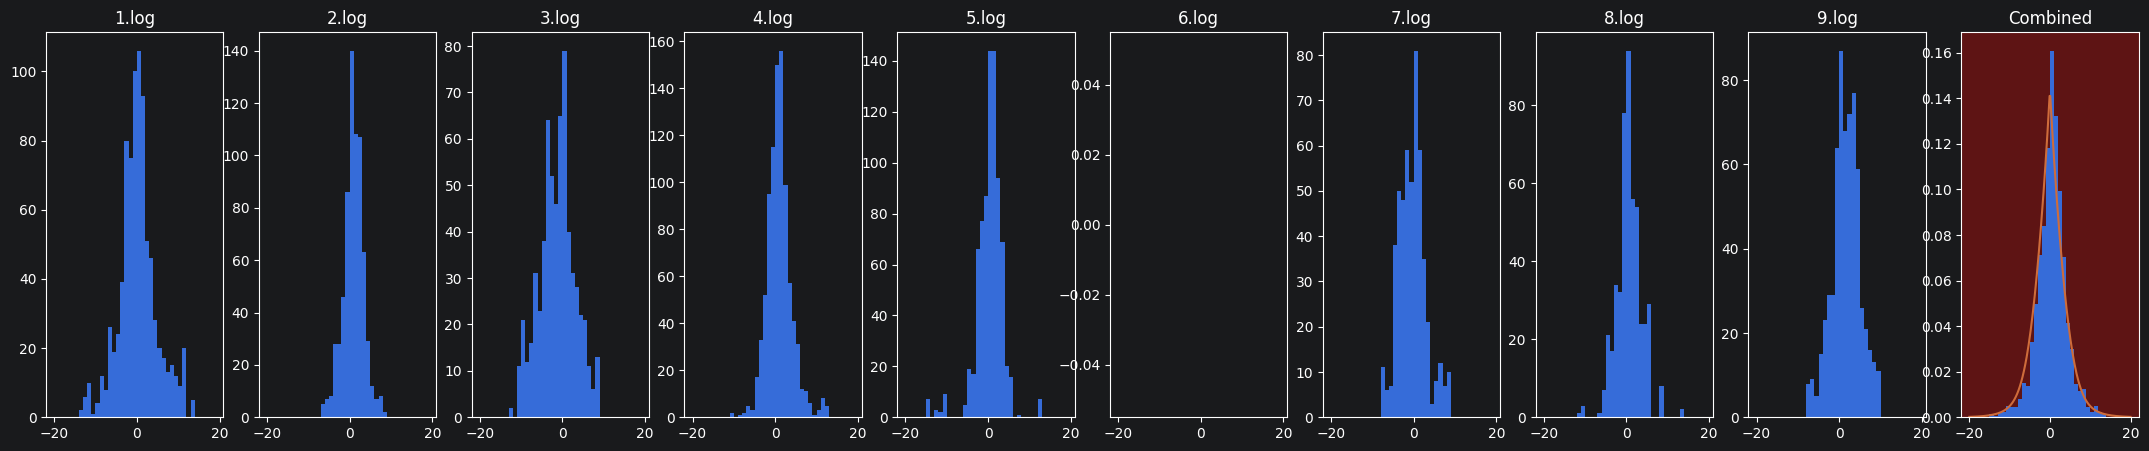

#### 255 to 285 Degrees

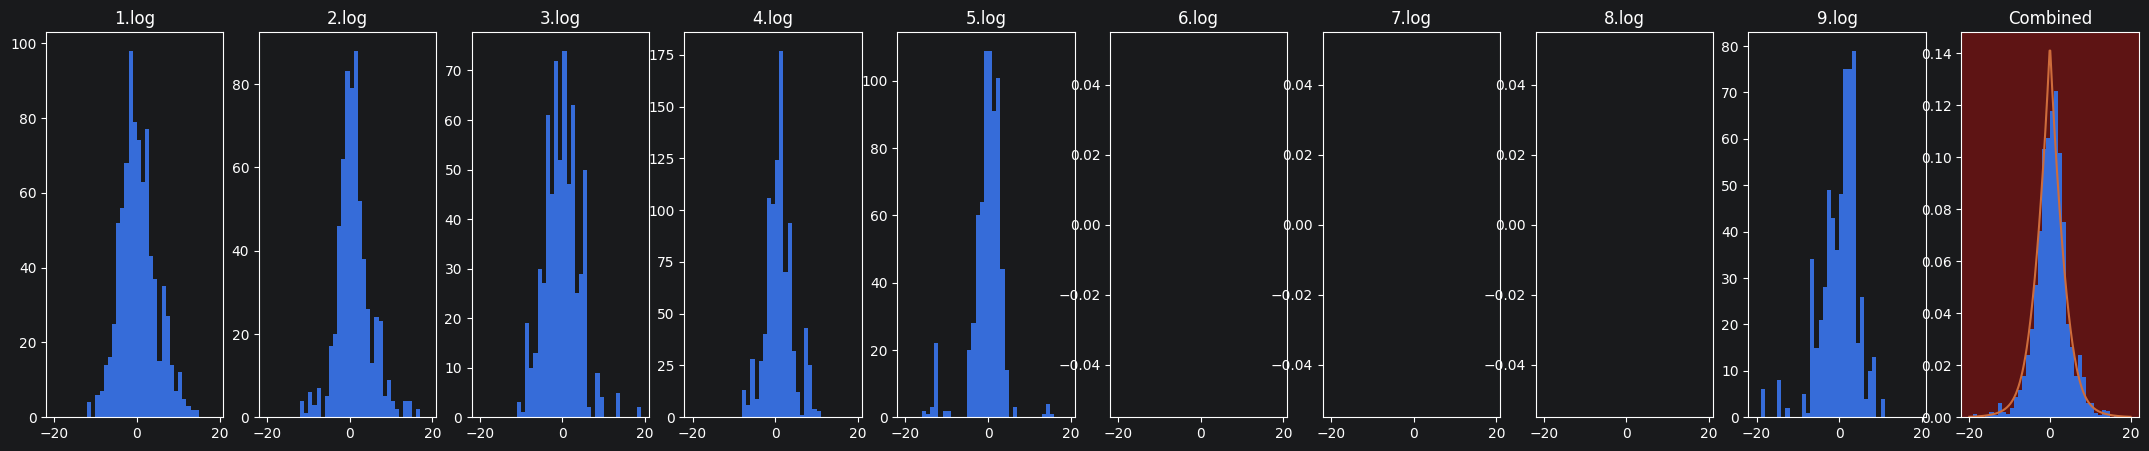

#### 285 to 315 Degrees

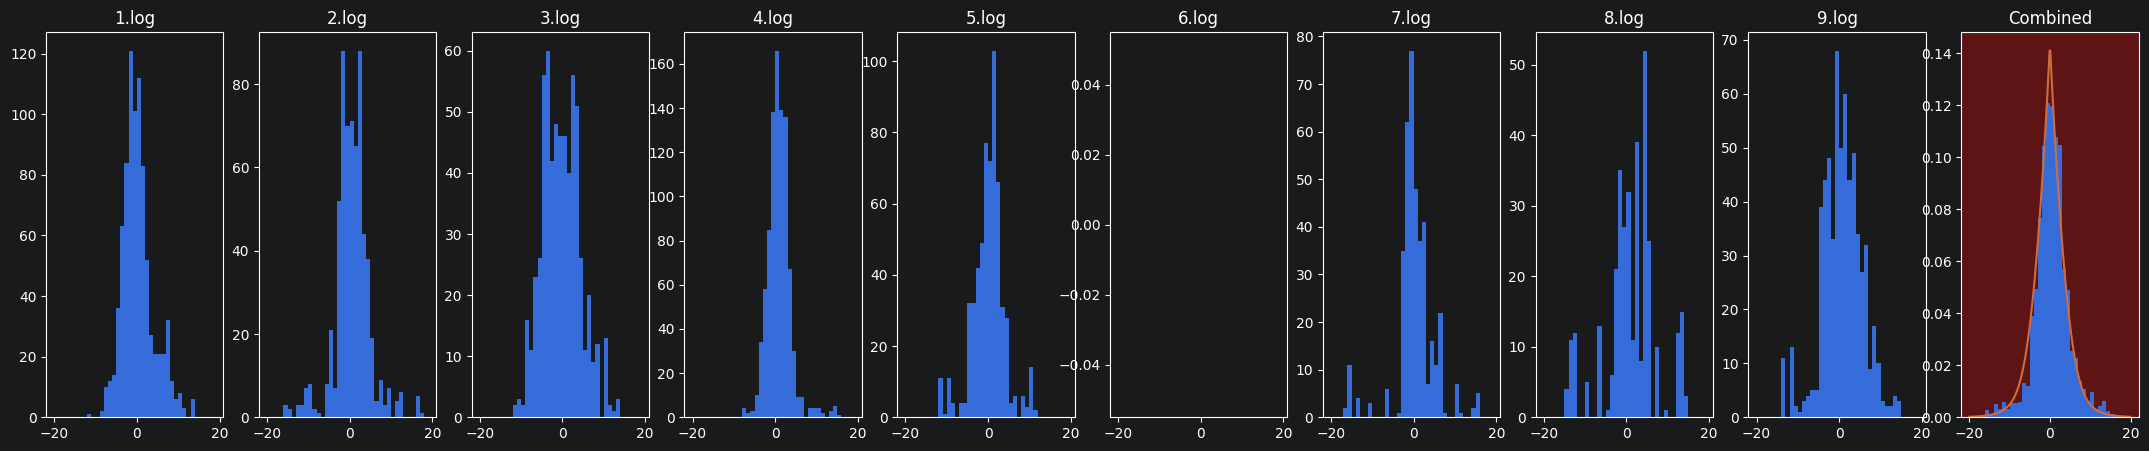

#### 315 to 345 Degrees

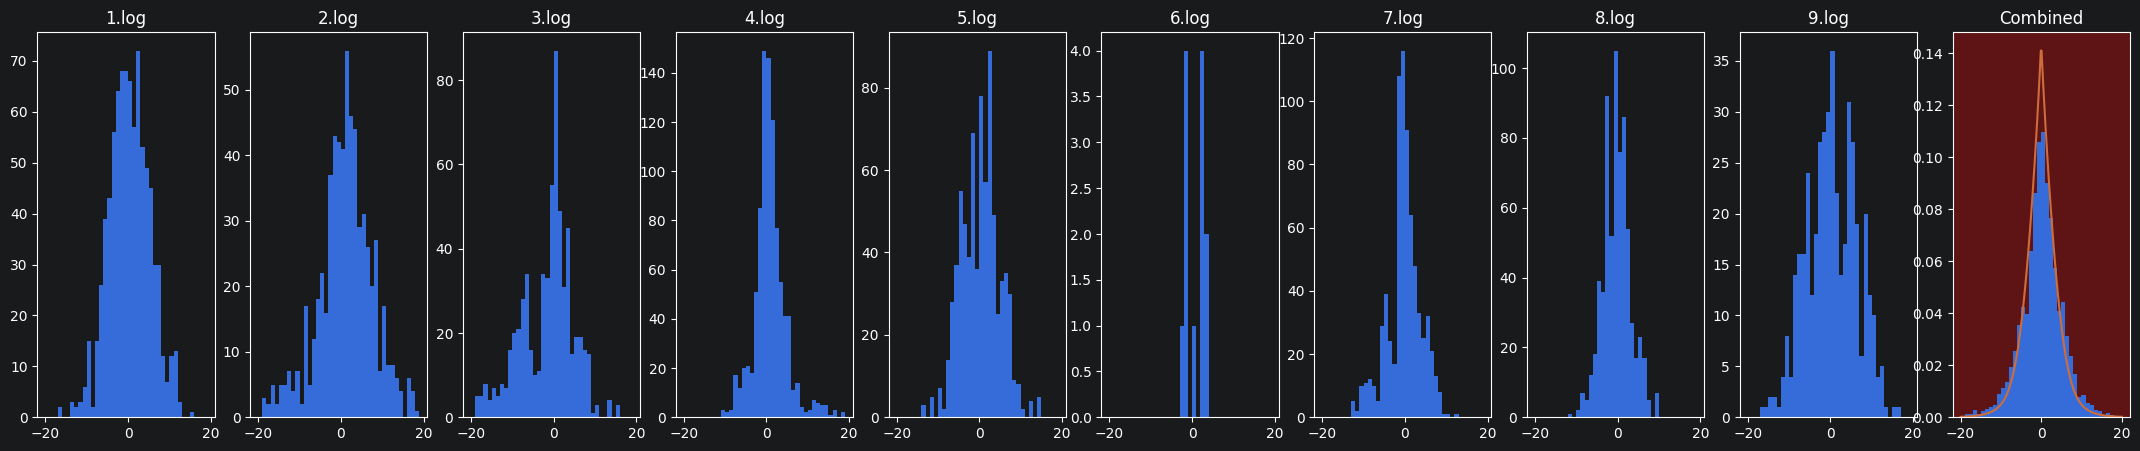

In [11]:
range_trial_rss_diffs_in_blocks(range_logs, 10)

### K-Means

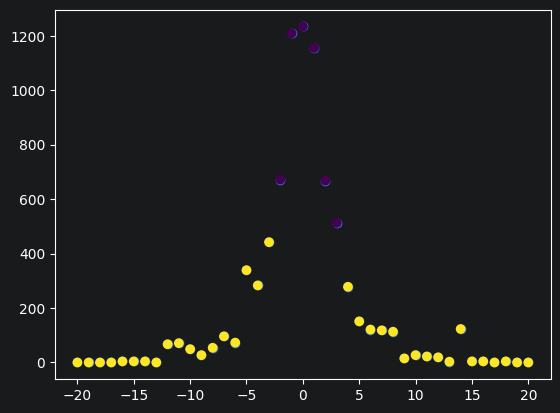

In [12]:
from sklearn.cluster import KMeans

freq_diff = [0] * 41 # [20] is diff of 0
rss = [-20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

for diff in diffs:
    try:
        freq_diff[diff + 20] += 1
    except:
        pass

plt.scatter(rss, freq_diff)

data = list(zip(rss, freq_diff))

kmeans = KMeans(n_clusters=2)
kmeans.fit(np.array(freq_diff).reshape(-1,1))

plt.scatter(rss, freq_diff, c=kmeans.labels_)

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (5 chains in 3 jobs)
NUTS: [mean_posterior, std_posterior]


Output()

Sampling 5 chains for 1_000 tune and 10_000 draw iterations (5_000 + 50_000 draws total) took 12 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mean_posterior,0.03,0.02,-0.02,0.07,0.0,0.0,52123.52,38106.63,1.0
std_posterior,1.66,0.02,1.64,1.69,0.0,0.0,52387.22,34933.28,1.0


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (5 chains in 3 jobs)
NUTS: [mean_posterior, std_posterior]


Output()

Sampling 5 chains for 1_000 tune and 10_000 draw iterations (5_000 + 50_000 draws total) took 11 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mean_posterior,0.14,0.16,-0.16,0.44,0.0,0.0,54051.60,37894.44,1.0
std_posterior,7.44,0.12,7.21,7.65,0.0,0.0,54448.42,37178.58,1.0


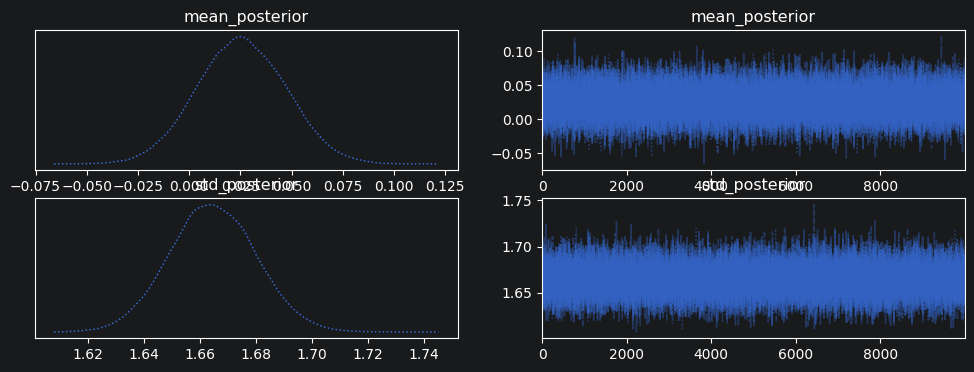

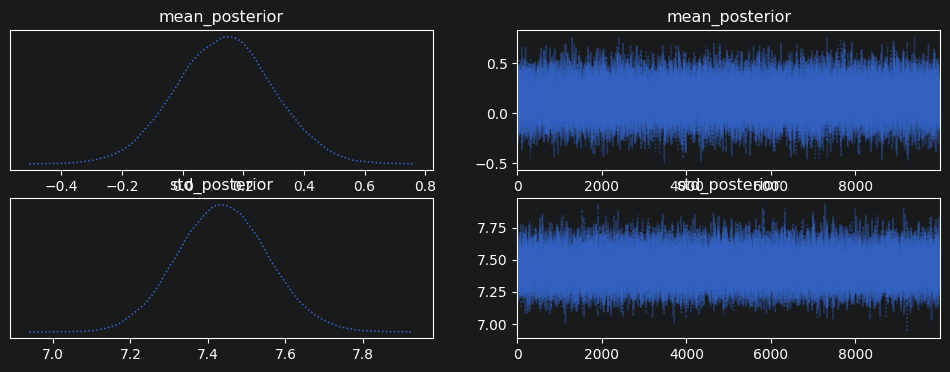

In [13]:
import pymc as pm
import arviz as az

diffs_pink = []

# filter out all "narrow" values
for diff in diffs:
    if -3 <= diff <= 3:
        diffs_pink.append(diff)

bee_wide_pink = pm.Model()

with bee_wide_pink:
    mean_prior = pm.Uniform("mean_posterior", lower=-3, upper=3)
    # mean_prior = pm.Normal("mean_posterior", mu=0, sigma=3)
    # std_prior = pm.HalfNormal("std_posterior", sigma=2)
    std_prior = pm.Uniform("std_posterior", lower=-5, upper=5)

    likelihood = pm.Normal("obs", mu=mean_prior, sigma=std_prior, observed=diffs_pink)

    trace_pink = pm.sample(10_000, chains=5)

az.plot_trace(trace_pink, combined=True)
summary_pink = az.summary(trace_pink, round_to=2)
display(summary_pink)

diffs_pink = []

# filter out all "narrow" values
for diff in diffs:
    if diff < -3 or diff > 3:
        diffs_pink.append(diff)

bee_wide_pink = pm.Model()

with bee_wide_pink:
    mean_prior = pm.Uniform("mean_posterior", lower=-10, upper=10)
    # mean_prior = pm.Normal("mean_posterior", mu=0, sigma=3)
    # std_prior = pm.HalfNormal("std_posterior", sigma=2)
    std_prior = pm.Uniform("std_posterior", lower=-17, upper=17)

    likelihood = pm.Normal("obs", mu=mean_prior, sigma=std_prior, observed=diffs_pink)

    trace_yellow = pm.sample(10_000, chains=5)

az.plot_trace(trace_yellow, combined=True)
summary_yellow = az.summary(trace_yellow, round_to=2)
display(summary_yellow)

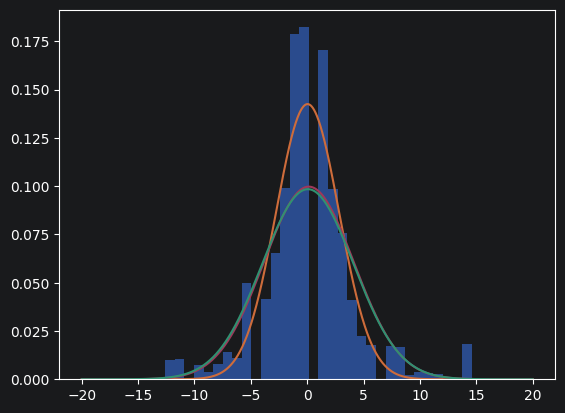

In [14]:
# plt.figure(figsize=(30, 30))
plt.hist(diffs, bins=40, alpha=0.6, density=True)

y_all = norm.pdf(x_axis, summary_pink.loc["mean_posterior", "mean"], 2.8)
y_wide = norm.pdf(x_axis, summary_yellow.loc["mean_posterior", "mean"],4.0)

plt.plot(x_axis, y_all)
plt.plot(x_axis, y_wide)

# normal over all diffs
all_mu, all_std = norm.fit(diffs)
all_norm = norm.pdf(x_axis, all_mu, all_std)
plt.plot(x_axis, all_norm)

plt.show()

## PyMC

Do inference on the data using PyMC to discover the true distribution of the data and that distribution's parameters

### Average $\Delta y$

In [15]:
d0_avg = np.mean(diffs_1)
d2_avg = np.mean(diffs_2)
d5_avg = np.mean(diffs_5)
d10_avg = np.mean(diffs_10)
total_avg = 0.25 * (d0_avg + d2_avg + d5_avg + d10_avg)

print(f"Means: \nD0: {d0_avg} \nD1: {d2_avg} \nD5: {d5_avg} \nD10: {d10_avg}")
print(f"Total Mean: {total_avg} or to 3SF: {total_avg:.4f}")

Means: 
D0: 0.02937248155023317 
D1: 0.02835997701176388 
D5: -0.013565203675223786 
D10: -0.18651291453568786
Total Mean: -0.03558641491222865 or to 3SF: -0.0356


### Normal

Just one normal distribution

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [sigma]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 7 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,3.749,0.009,3.731,3.765,0.0,0.0,2498.0,4285.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


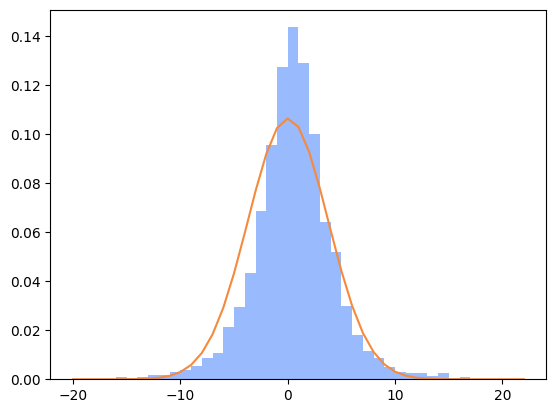

In [12]:
learn_normal(diffs_1)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [sigma]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 8 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,3.863,0.009,3.846,3.881,0.0,0.0,2573.0,4154.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


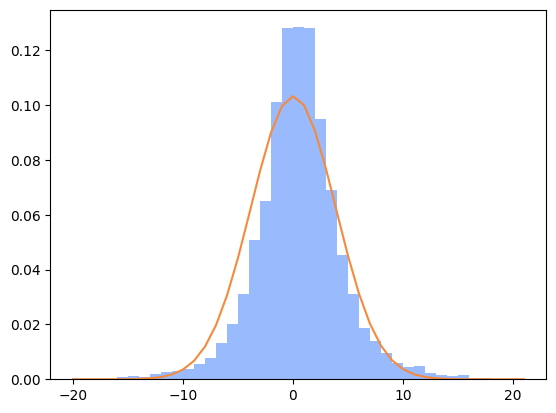

In [6]:
learn_normal(diffs_2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [sigma]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 6 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,4.099,0.011,4.081,4.12,0.0,0.0,2413.0,4076.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


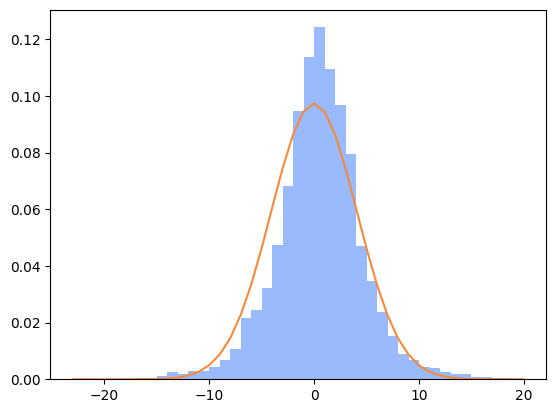

In [13]:
learn_normal(diffs_5)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [sigma]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,4.278,0.012,4.255,4.299,0.0,0.0,2738.0,4160.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


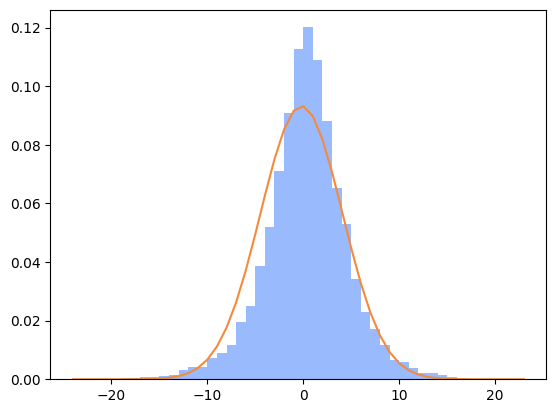

In [14]:
learn_normal(diffs_10)

### Two Normals

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma1, sigma2]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 3_000 draw iterations (3_000 + 9_000 draws total) took 343 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma1,3.626,1.606,2.452,5.953,0.926,0.328,5.0,34.0,1.66
sigma2,4.762,1.606,2.460,5.975,0.926,0.327,5.0,35.0,1.66
w[0],0.575,0.212,0.265,0.737,0.122,0.043,5.0,35.0,1.66
w[1],0.425,0.212,0.263,0.735,0.122,0.043,5.0,35.0,1.66


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


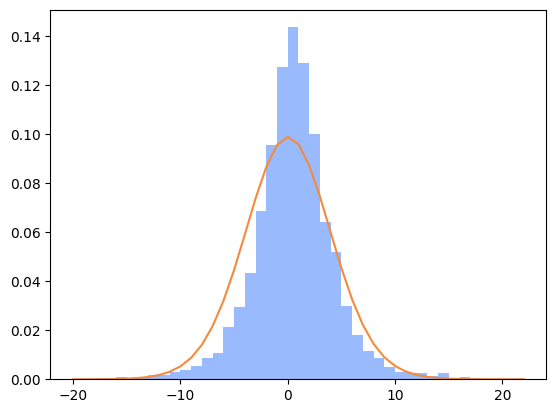

In [30]:
learn_norm_norm_mix(diffs_1)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma1, sigma2]


Output()

Sampling 3 chains for 1_000 tune and 3_000 draw iterations (3_000 + 9_000 draws total) took 390 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma1,3.658,1.593,2.489,5.962,0.918,0.325,5.0,31.0,1.66
sigma2,4.785,1.594,2.500,5.987,0.919,0.325,5.0,33.0,1.66
w[0],0.567,0.190,0.289,0.714,0.109,0.039,5.0,33.0,1.66
w[1],0.433,0.190,0.286,0.711,0.109,0.039,5.0,33.0,1.66


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


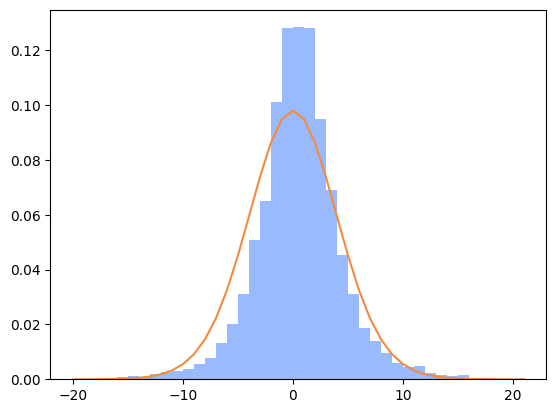

In [7]:
learn_norm_norm_mix(diffs_2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma1, sigma2]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 3_000 draw iterations (3_000 + 9_000 draws total) took 257 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma1,3.886,1.532,2.750,6.119,0.883,0.313,5.0,38.0,1.66
sigma2,4.968,1.532,2.762,6.148,0.883,0.312,5.0,32.0,1.66
w[0],0.563,0.178,0.298,0.707,0.103,0.036,5.0,33.0,1.66
w[1],0.437,0.178,0.293,0.702,0.103,0.036,5.0,33.0,1.66


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


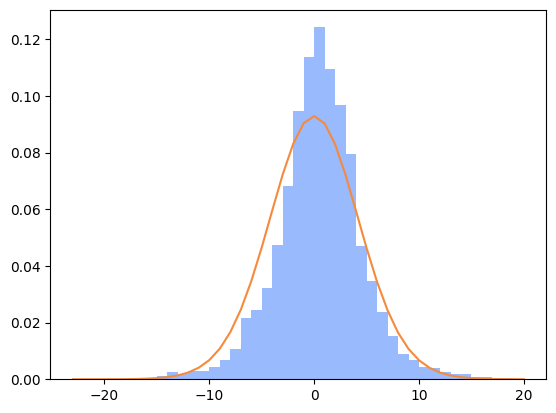

In [31]:
learn_norm_norm_mix(diffs_5)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma1, sigma2]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 3_000 draw iterations (3_000 + 9_000 draws total) took 203 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma1,3.823,1.494,2.698,5.995,0.861,0.305,5.0,38.0,1.66
sigma2,4.880,1.497,2.713,6.026,0.863,0.305,5.0,41.0,1.67
w[0],0.538,0.108,0.370,0.634,0.062,0.022,5.0,34.0,1.66
w[1],0.462,0.108,0.366,0.630,0.062,0.022,5.0,34.0,1.66


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


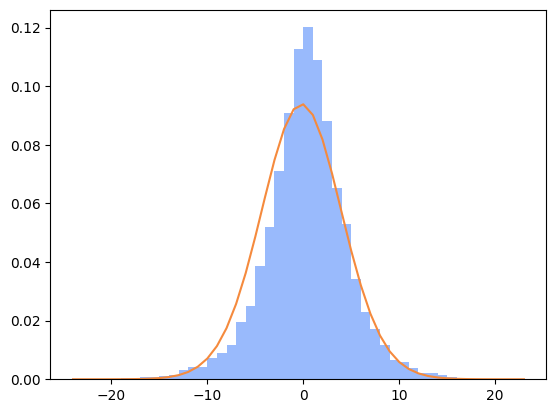

In [32]:
learn_norm_norm_mix(diffs_10)

### Three Normals

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 776 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma[0],4.047,1.611,2.827,6.405,0.928,0.328,5.0,33.0,1.67
sigma[1],1.320,0.068,1.197,1.450,0.002,0.001,1759.0,2130.0,1.00
sigma[2],5.184,1.608,2.853,6.441,0.926,0.327,5.0,38.0,1.66
w[0],0.510,0.216,0.194,0.683,0.124,0.044,5.0,34.0,1.67
w[1],0.132,0.016,0.104,0.163,0.000,0.000,1615.0,2063.0,1.00
w[2],0.358,0.215,0.190,0.677,0.124,0.044,5.0,36.0,1.66


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


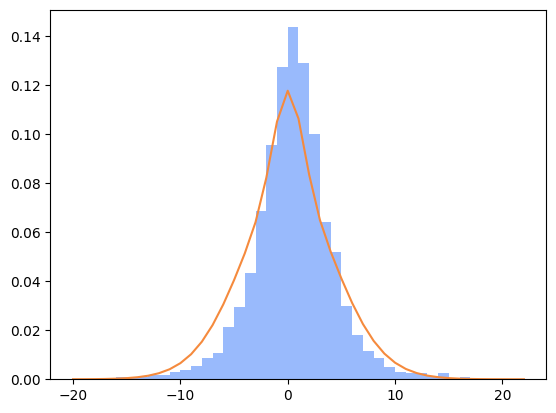

In [8]:
learn_triple_norm_mix(diffs_1)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 862 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma[0],6.181,0.066,6.062,6.310,0.001,0.001,2380.0,2305.0,1.00
sigma[1],2.479,0.611,1.506,3.017,0.350,0.125,5.0,41.0,1.66
sigma[2],2.052,0.609,1.470,2.991,0.348,0.121,5.0,34.0,1.66
w[0],0.246,0.009,0.229,0.264,0.000,0.000,2283.0,2853.0,1.00
w[1],0.453,0.219,0.112,0.647,0.125,0.044,5.0,35.0,1.66
w[2],0.301,0.219,0.106,0.642,0.125,0.044,5.0,40.0,1.66


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


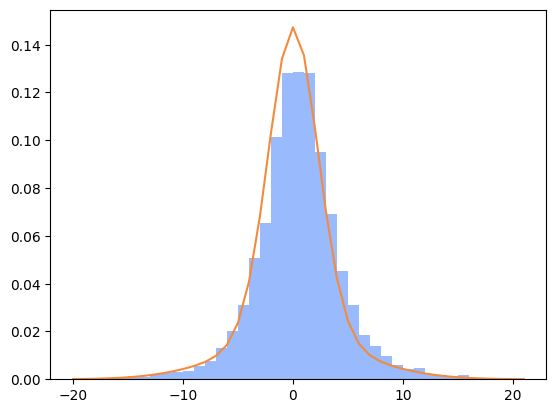

In [9]:
learn_triple_norm_mix(diffs_2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 734 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma[0],3.955,1.886,1.868,6.612,1.086,0.384,4.0,38.0,2.37
sigma[1],4.430,1.459,3.266,6.605,0.839,0.297,5.0,42.0,1.66
sigma[2],3.478,2.131,1.830,6.608,1.227,0.434,5.0,37.0,1.66
w[0],0.334,0.169,0.171,0.608,0.097,0.034,4.0,35.0,1.83
w[1],0.455,0.165,0.205,0.612,0.094,0.033,5.0,39.0,1.66
w[2],0.212,0.027,0.154,0.256,0.004,0.003,42.0,1053.0,1.07


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


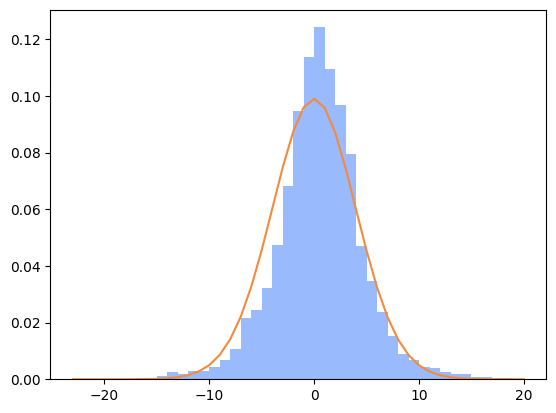

In [10]:
learn_triple_norm_mix(diffs_5)

In [ ]:
learn_triple_norm_mix(diffs_10)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma]


Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, mean, sigma]


Output()

Sampling 3 chains for 1_000 tune and 700 draw iterations (3_000 + 2_100 draws total) took 35 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


array([[<Axes: title={'center': 'mean'}>,
        <Axes: title={'center': 'mean'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'w'}>, <Axes: title={'center': 'w'}>]],
      dtype=object)

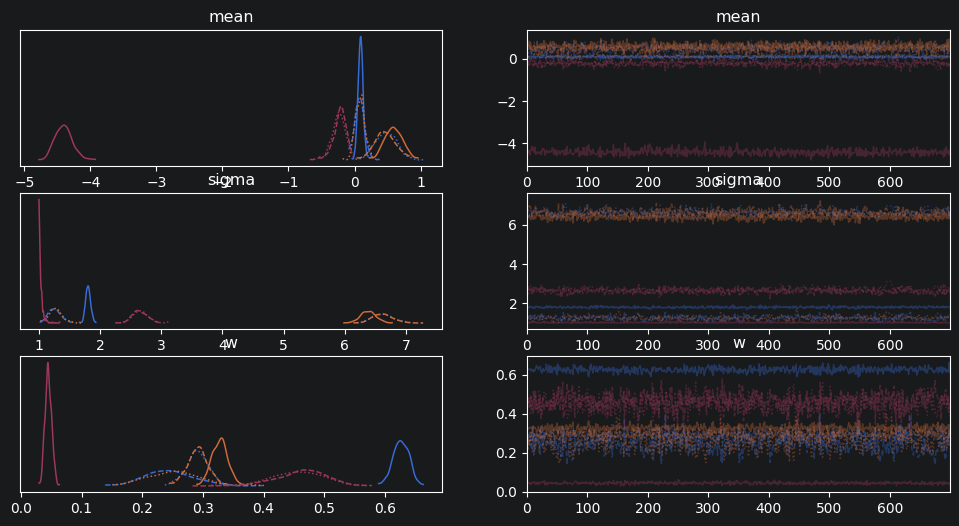

In [16]:
import pymc as pm
import arviz as az

mix_bee_model = pm.Model()

with mix_bee_model:
    # w = pm.Beta("w", alpha=1, beta=1)
    w = pm.Dirichlet("w", a=np.ones(3))
    mean = pm.Normal("mean", mu=0, sigma=1, shape=3)
    # sigma = pm.HalfNormal("sigma", sigma=5, shape=3)
    sigma = pm.Uniform("sigma", lower=1, upper=15, shape=3)

    components = pm.Normal.dist(mu=mean, sigma=sigma, shape=3)

    y = pm.Mixture("y", w=w, comp_dists=components, observed=diffs)

with mix_bee_model:
    trace = pm.sample(2000, tune=1000, return_inferencedata=True)

az.summary(trace)
az.plot_trace(trace)

In [17]:
display(az.summary(trace))

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mean[0],0.216,0.213,-0.046,0.650,0.109,0.047,5.0,42.0,1.66
mean[1],0.381,0.251,-0.031,0.765,0.126,0.029,5.0,41.0,1.73
mean[2],-1.622,1.971,-4.556,-0.067,1.130,0.400,5.0,36.0,1.67
sigma[0],3.228,2.414,1.104,6.800,1.385,0.491,4.0,63.0,2.37
sigma[1],4.758,2.470,1.127,6.827,1.416,0.500,4.0,42.0,2.03
sigma[2],2.114,0.773,1.000,2.821,0.440,0.153,5.0,52.0,1.67
w[0],0.388,0.172,0.204,0.648,0.098,0.034,4.0,36.0,1.96
w[1],0.291,0.042,0.202,0.353,0.018,0.008,5.0,52.0,1.53
w[2],0.321,0.198,0.035,0.515,0.112,0.038,5.0,37.0,1.67


### Cauchy Distribution

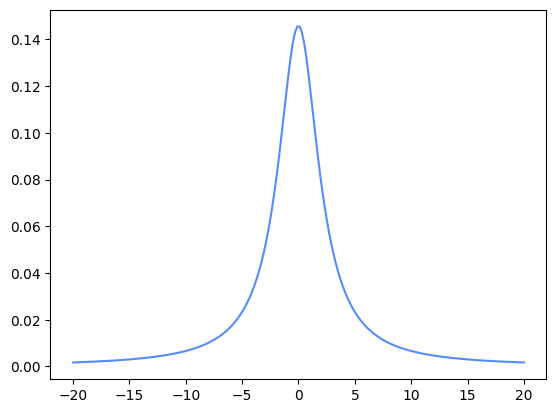

In [15]:
from scipy.stats import cauchy

x_axis = np.linspace(-20, 20, 40*5)
y_e1 = cauchy.pdf(x_axis, scale=2.183)

plt.plot(x_axis, y_e1)
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [beta]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 22 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,1.854,0.008,1.837,1.869,0.0,0.0,2812.0,4079.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


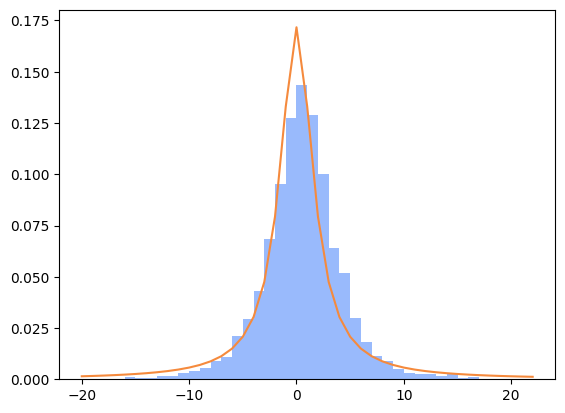

In [16]:
learn_cauchy(diffs_1)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [beta]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 20 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,1.94,0.009,1.925,1.958,0.0,0.0,2485.0,3558.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


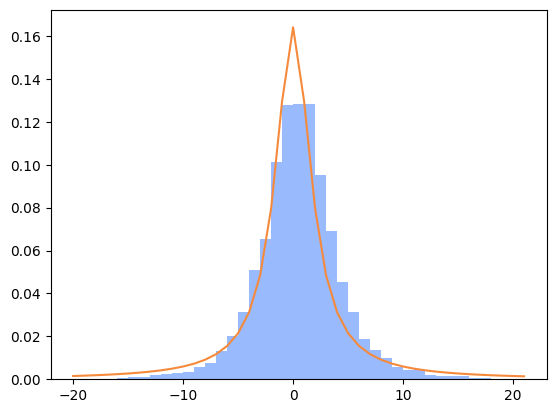

In [17]:
learn_cauchy(diffs_2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [beta]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 18 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,2.124,0.01,2.106,2.143,0.0,0.0,2521.0,4122.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


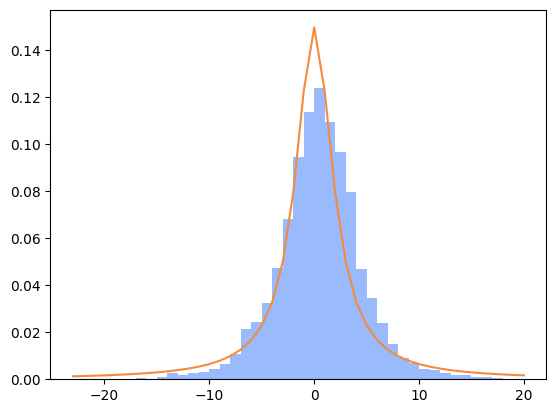

In [18]:
learn_cauchy(diffs_5)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [beta]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 16 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,2.212,0.012,2.19,2.234,0.0,0.0,2642.0,4494.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


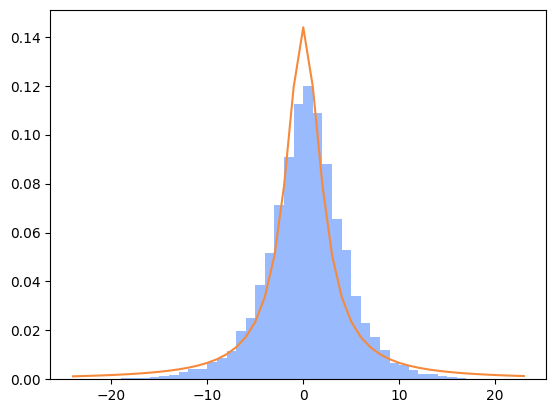

In [19]:
learn_cauchy(diffs_10)

### Cauchy and Normal Mixture Model

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, beta]


Output()

Sampling 3 chains for 2_000 tune and 1_000 draw iterations (6_000 + 3_000 draws total) took 219 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,1.151,0.022,1.109,1.193,0.0,0.0,2030.0,1983.0,1.0
sigma,3.550,0.016,3.520,3.580,0.0,0.0,1598.0,1804.0,1.0
w[0],0.742,0.005,0.734,0.752,0.0,0.0,2206.0,2052.0,1.0
w[1],0.258,0.005,0.248,0.266,0.0,0.0,2206.0,2052.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


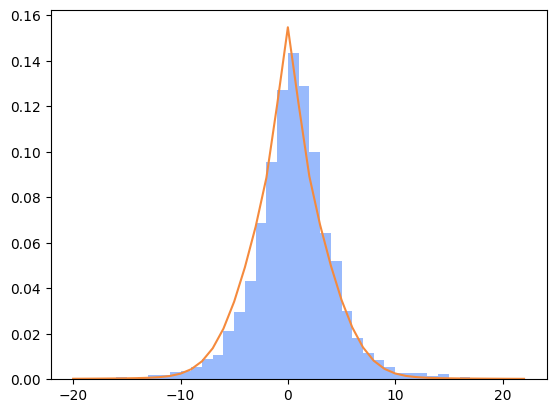

In [23]:
learn_cauchy_norm_mix(diffs_1)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, beta]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 2_000 tune and 1_000 draw iterations (6_000 + 3_000 draws total) took 214 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,0.879,0.601,0.029,1.335,0.345,0.122,5.0,36.0,1.66
sigma,3.791,0.203,3.622,4.093,0.117,0.041,5.0,34.0,1.66
w[0],0.796,0.060,0.747,0.883,0.034,0.012,5.0,36.0,1.66
w[1],0.204,0.060,0.117,0.253,0.034,0.012,5.0,36.0,1.66


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


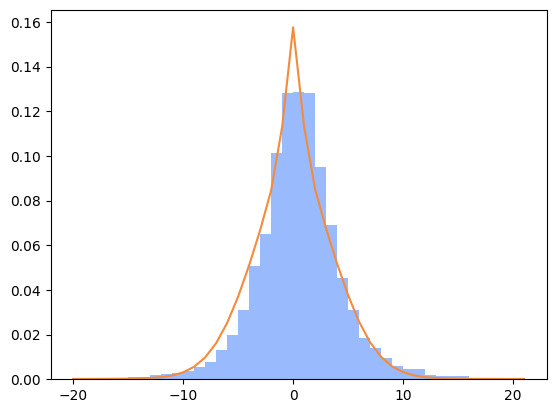

In [24]:
learn_cauchy_norm_mix(diffs_2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, beta]


Output()

Sampling 3 chains for 2_000 tune and 1_000 draw iterations (6_000 + 3_000 draws total) took 188 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,1.233,0.031,1.171,1.288,0.001,0.001,1806.0,2054.0,1.0
sigma,3.980,0.017,3.950,4.013,0.000,0.000,2081.0,2225.0,1.0
w[0],0.803,0.005,0.794,0.812,0.000,0.000,2056.0,1989.0,1.0
w[1],0.197,0.005,0.188,0.206,0.000,0.000,2056.0,1989.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


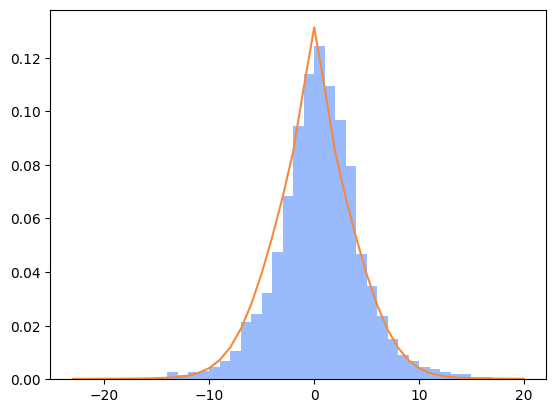

In [25]:
learn_cauchy_norm_mix(diffs_5)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, beta]


Output()

Sampling 3 chains for 2_000 tune and 1_000 draw iterations (6_000 + 3_000 draws total) took 159 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,1.120,0.030,1.064,1.176,0.001,0.001,1870.0,1983.0,1.0
sigma,4.273,0.018,4.238,4.306,0.000,0.000,1984.0,1926.0,1.0
w[0],0.811,0.005,0.801,0.822,0.000,0.000,2067.0,2014.0,1.0
w[1],0.189,0.005,0.178,0.199,0.000,0.000,2067.0,2014.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


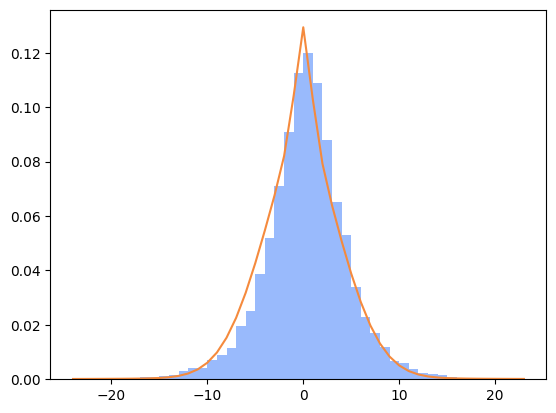

In [26]:
learn_cauchy_norm_mix(diffs_10)

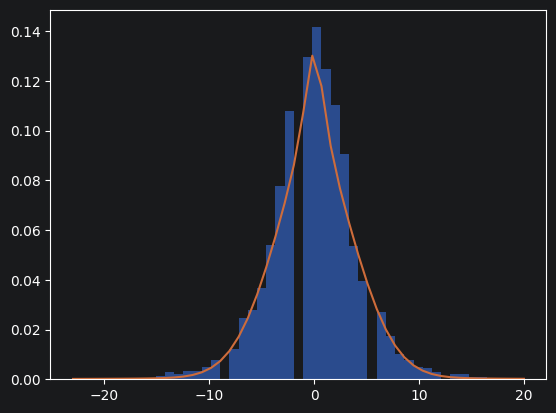

In [26]:
# plot PDF over histogram
x_vals = np.linspace(min(diffs_5), max(diffs_5))
plt.hist(diffs_5, bins=x_vals, alpha=0.6, density=True)

w = 0.803
c = cauchy.pdf(x_vals, scale=1.234)
n = norm.pdf(x_vals, 0, 3.980)

mix = w * n + (1 - w) * c

plt.plot(x_vals, mix)
plt.show()

#### Manual Parameter Experimentation

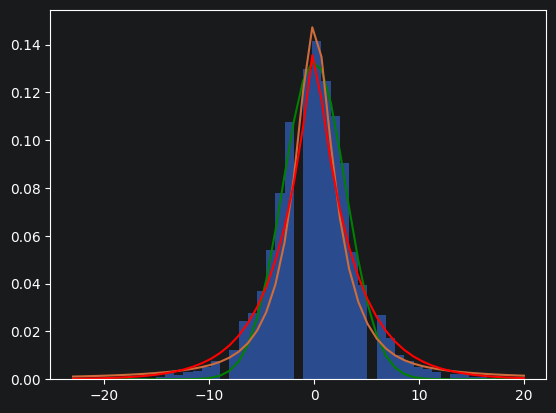

In [25]:
from scipy.stats import laplace

x_vals = np.linspace(min(diffs_5), max(diffs_5))
plt.hist(diffs_5, bins=x_vals, alpha=0.6, density=True)

c = cauchy.pdf(x_vals, scale=2.123)
n = norm.pdf(x_vals, 0, 3)
l = laplace.pdf(x_vals, loc=0, scale=3.5)

mix = 0.1 * n + 0.9 * c
# mix = (1 - 10**-10) * n + 10**-10 * c

# plt.plot(x_vals, c, 'red')
plt.plot(x_vals, n, 'green')
plt.plot(x_vals, mix)
plt.plot(x_vals, l, 'red')
plt.show()

### Laplace

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [std]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
std,2.695,0.009,2.679,2.713,0.0,0.0,2561.0,4124.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


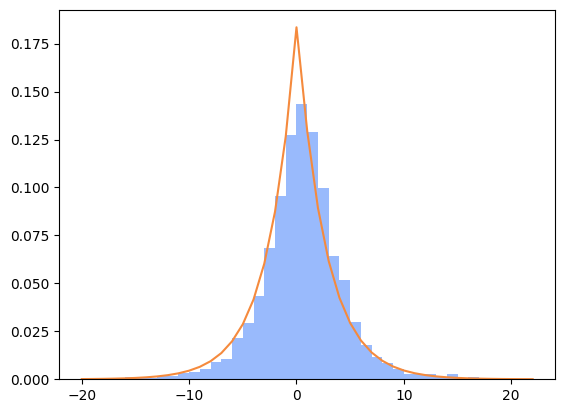

In [20]:
learn_laplace(diffs_1)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [std]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 6 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
std,2.8,0.01,2.782,2.818,0.0,0.0,2224.0,3926.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


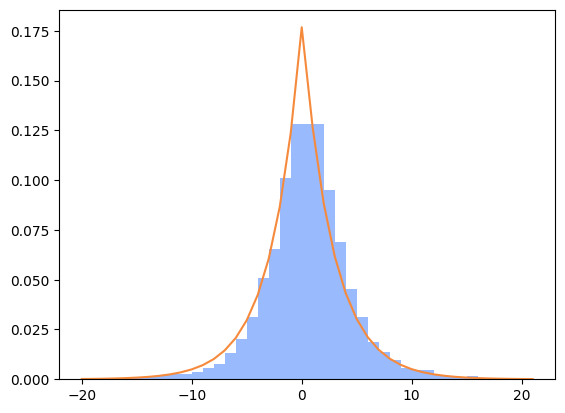

In [7]:
learn_laplace(diffs_2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [std]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
std,3.011,0.011,2.99,3.031,0.0,0.0,2638.0,3755.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


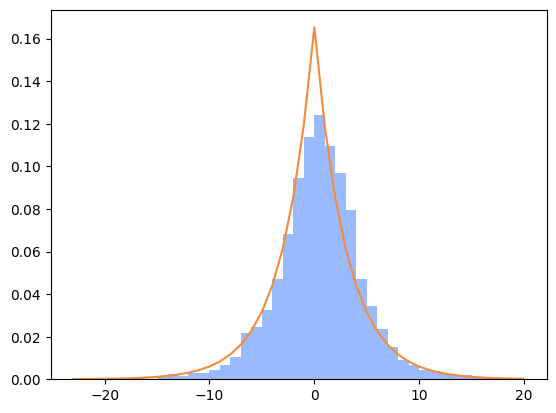

In [21]:
learn_laplace(diffs_5)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [std]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
std,3.169,0.013,3.147,3.195,0.0,0.0,2835.0,4133.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


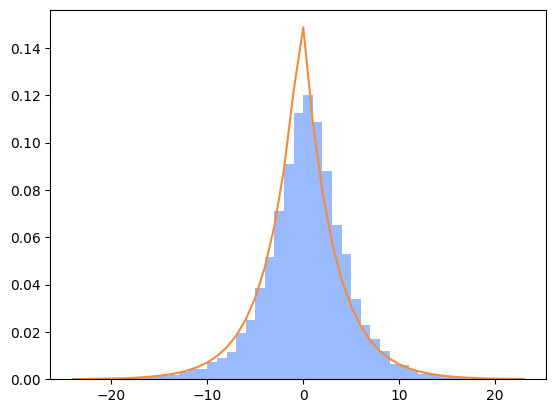

In [22]:
learn_laplace(diffs_10)

### Laplace and Normal Mixture

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, b]


Output()

Sampling 3 chains for 1_000 tune and 3_000 draw iterations (3_000 + 9_000 draws total) took 297 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,2.839,0.019,2.804,2.875,0.000,0.0,4343.0,4822.0,1.0
sigma,2.864,0.037,2.788,2.928,0.001,0.0,4450.0,5348.0,1.0
w[0],0.263,0.013,0.239,0.287,0.000,0.0,4810.0,5416.0,1.0
w[1],0.737,0.013,0.713,0.761,0.000,0.0,4810.0,5416.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


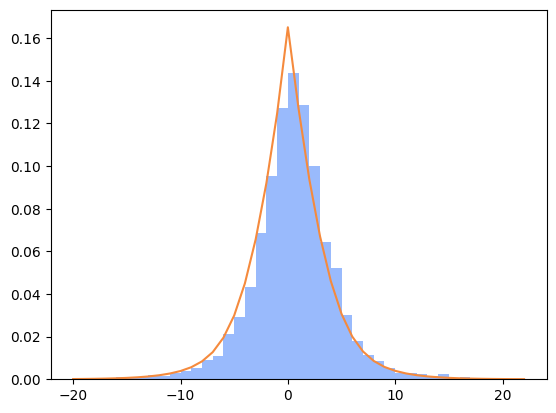

In [27]:
learn_laplace_norm_mix(diffs_1)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, b]


Output()

Sampling 3 chains for 1_000 tune and 3_000 draw iterations (3_000 + 9_000 draws total) took 264 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,3.036,0.024,2.991,3.081,0.0,0.0,4033.0,4817.0,1.0
sigma,2.890,0.032,2.829,2.949,0.0,0.0,4458.0,5304.0,1.0
w[0],0.327,0.013,0.302,0.351,0.0,0.0,4357.0,4942.0,1.0
w[1],0.673,0.013,0.649,0.698,0.0,0.0,4357.0,4942.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


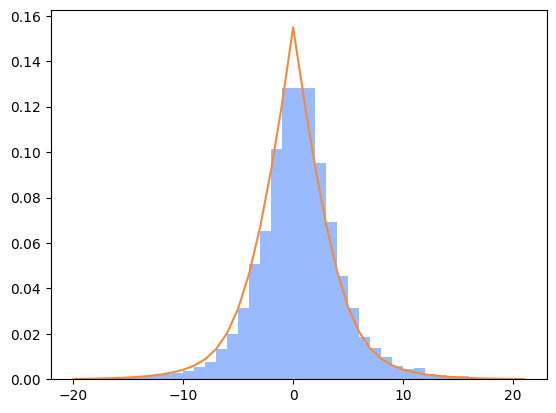

In [8]:
learn_laplace_norm_mix(diffs_2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, b]


Output()

Sampling 3 chains for 1_000 tune and 3_000 draw iterations (3_000 + 9_000 draws total) took 184 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,3.155,0.026,3.108,3.203,0.000,0.0,4091.0,5335.0,1.0
sigma,3.447,0.041,3.369,3.522,0.001,0.0,4261.0,5479.0,1.0
w[0],0.360,0.013,0.335,0.385,0.000,0.0,4578.0,5475.0,1.0
w[1],0.640,0.013,0.615,0.665,0.000,0.0,4578.0,5475.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


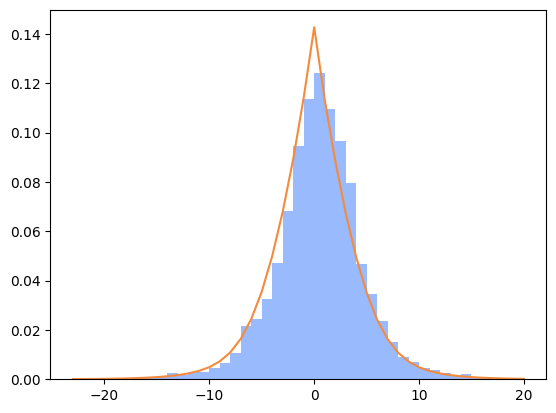

In [28]:
learn_laplace_norm_mix(diffs_5)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, b]


Output()

Sampling 3 chains for 1_000 tune and 3_000 draw iterations (3_000 + 9_000 draws total) took 163 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,3.335,0.035,3.270,3.402,0.001,0.000,4142.0,4142.0,1.0
sigma,3.646,0.052,3.544,3.741,0.001,0.001,4645.0,4945.0,1.0
w[0],0.392,0.015,0.365,0.420,0.000,0.000,4471.0,5035.0,1.0
w[1],0.608,0.015,0.580,0.635,0.000,0.000,4471.0,5035.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


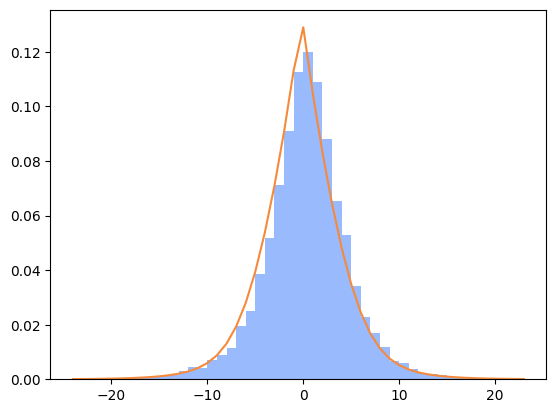

In [29]:
learn_laplace_norm_mix(diffs_10)